# Analysis of wavefront sensor data from ALS 5.3.1

Date: Created May 2026 · Last edited 2026-06-24

Author: Wei "Francis" He (francisho@lbl.gov, whorwhey@gmail.com)

Based on earlier versions by Dr. Antoine Islegen-Wojdyla (awojdyla@lbl.gov) and myself. 

___

## Overview

This notebook is created from the templates that designed for analyzing data taken at BL 5.3.1 via Bluesky. 

More specifically, this very script is for data taken on 2026-05-29 by Francis and Henry. 


# SETUP 

## Import 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from tiled.client import from_uri
import os, pickle
import time

import warnings
warnings.simplefilter('always', RuntimeWarning)

In [2]:
import monoplus as mp
import wfs_live as wfl

## Access Data from the Server


__Tiled connection__

>Note: We tried read data from db with `tiled.__version__='0.2.9'`, but it failed; \
>had to reinstall a 0.2.1 version to make it work. 

In [3]:
# --- Server connection ---
api_key_path = "/Users/francisho/Documents/TILED_SINGLE_USER_API_KEY.txt"   # Change this path to where your API key is stored 

with open(api_key_path, "r") as f:
    api_key = f.read().strip()

if not api_key:
    raise ValueError("API key file is empty or not found.")

tiled_client = from_uri("http://131.243.80.226:8000", api_key=api_key)

__Dataset registry__

In [4]:
# --- Camera / objective (shared across scans) ---
# Camera / objective metadata is stored in each scan's md
# PIXEL_SIZE_M       = 2.4e-6
# OBJECTIVE_MAG      = 5
# EFF_PIXEL_M        = PIXEL_SIZE_M / OBJECTIVE_MAG    # ~0.48 µm/px

Z_GD_M             = 0.3                              # grating to detector distance (m)

# --- Dataset registry ---
# Keys: chip{N}_{grid|lin}_{tag}.  bender ranges: 'neg' = -2000:-1400 (good),
# 'zero' = -400:0 (near-zero, lower quality).  Linear: 'near' = at-chip,
# 'far' = downstream caustic.
DATASETS = {
    # ── Chip 1 (7.0 µm pitch, bcs_linear_motor ≈ 4.41 mm) ──────────────
    "chip1_grid_neg": dict(
        uid="4adb81df-534d-4fc9-8590-ab1a449e5b54",
        chip=1, grating_pitch_m=7.0e-6,
        scan_type="grid",
        outer=("mono_energy_energy_eV", 7000, 9000, 11),
        inner=("bender_um",            -2000, -1400, 13),
        fixed=dict(bcs_linear_motor=4.410),
    ),
    "chip1_grid_zero": dict(
        uid="f87cf0d3-ab99-464b-81fa-73d9d892f374",
        chip=1, grating_pitch_m=7.0e-6,
        scan_type="grid",
        outer=("mono_energy_energy_eV", 7000, 9000, 11),
        inner=("bender_um",            -400, 0, 9),
        fixed=dict(bcs_linear_motor=4.410),
    ),
    "chip1_lin_near": dict(
        uid="a9a6beac-9762-4cfb-939f-d5d18beb9541",
        chip=1, grating_pitch_m=7.0e-6,
        scan_type="linear",
        axis=("bcs_linear_motor_mm", 4.410, 4.600, 191),
        fixed=dict(mono_energy=8000, bender_um=-2000),
    ),
    "chip1_lin_far": dict(
        uid="ce368e98-65b2-4059-a954-2a2d05c21dbc",
        chip=1, grating_pitch_m=7.0e-6,
        scan_type="linear",
        axis=("bcs_linear_motor_mm", 5.500, 5.700, 201),
        fixed=dict(mono_energy=8000, bender_um=-2000),
    ),
    # ── Chip 2 (6.2 µm pitch, bcs_linear_motor ≈ 7.90 mm) ──────────────
    "chip2_grid_neg": dict(
        uid="5dbef69f-1e5b-43f3-8950-7118053075a1",
        chip=2, grating_pitch_m=6.2e-6,
        scan_type="grid",
        outer=("mono_energy_energy_eV", 7000, 9000, 11),
        inner=("bender_um",            -2000, -1400, 13),
        fixed=dict(bcs_linear_motor=7.900),
    ),
    "chip2_grid_zero": dict(
        uid="301119ed-ad7c-4c58-b8c6-ef5c92a52115",
        chip=2, grating_pitch_m=6.2e-6,
        scan_type="grid",
        outer=("mono_energy_energy_eV", 7000, 9000, 11),
        inner=("bender_um",            -400, 0, 9),
        fixed=dict(bcs_linear_motor=7.900),
    ),
    "chip2_lin_near": dict(
        uid="a0883ecc-84b2-4096-9ee3-5f46e061a9b0",
        chip=2, grating_pitch_m=6.2e-6,
        scan_type="linear",
        axis=("bcs_linear_motor_mm", 7.901, 8.100, 200),
        fixed=dict(mono_energy=8000, bender_um=-2000),
    ),
    "chip2_lin_far": dict(
        uid="67396878-25a5-459d-a6b5-cd0fe571a6f0",
        chip=2, grating_pitch_m=6.2e-6,
        scan_type="linear",
        axis=("bcs_linear_motor_mm", 8.900, 9.100, 201),
        fixed=dict(mono_energy=8000, bender_um=-2000),
    ),
}

# --- Per-chip analysis defaults (to be filled in Section B) ---
CHIP_DEFAULTS = {
    1: dict(y_roi=None, tilt_rad=None, V_threshold=0.4, I0_threshold=0.02),
    2: dict(y_roi=None, tilt_rad=None, V_threshold=0.4, I0_threshold=0.02),
}

for k, d in DATASETS.items():
    print(f"{k:20s}  chip={d['chip']}  pitch={d['grating_pitch_m']*1e6:.1f} µm  "
          f"{d['scan_type']:6s}  uid={d['uid'][:]}")

chip1_grid_neg        chip=1  pitch=7.0 µm  grid    uid=4adb81df-534d-4fc9-8590-ab1a449e5b54
chip1_grid_zero       chip=1  pitch=7.0 µm  grid    uid=f87cf0d3-ab99-464b-81fa-73d9d892f374
chip1_lin_near        chip=1  pitch=7.0 µm  linear  uid=a9a6beac-9762-4cfb-939f-d5d18beb9541
chip1_lin_far         chip=1  pitch=7.0 µm  linear  uid=ce368e98-65b2-4059-a954-2a2d05c21dbc
chip2_grid_neg        chip=2  pitch=6.2 µm  grid    uid=5dbef69f-1e5b-43f3-8950-7118053075a1
chip2_grid_zero       chip=2  pitch=6.2 µm  grid    uid=301119ed-ad7c-4c58-b8c6-ef5c92a52115
chip2_lin_near        chip=2  pitch=6.2 µm  linear  uid=a0883ecc-84b2-4096-9ee3-5f46e061a9b0
chip2_lin_far         chip=2  pitch=6.2 µm  linear  uid=67396878-25a5-459d-a6b5-cd0fe571a6f0


## Helper Functions

Two utilities used throughout the rest of the notebook:

- **`load_scan(key)`** — pull a registered scan from Tiled. Returns `(images, meta, info)`, where `meta` is a dict of per-frame 1-D arrays (`mono_energy_eV`, `bender_um`, or `bcs_linear_motor_mm` depending on `scan_type`) and `info` carries the resolved shape and registry metadata.
- **`frame_label(key, idx, meta, info)`** — formatted string for plot titles and log lines, e.g. `"chip1_grid_neg (chip1)  idx=67  E=8000 eV  B=-1900 µm"`.

In [15]:
def load_scan(key, verbose=True):
    """Load a registered scan from Tiled.

    Returns
    -------
    images : (N, H, W) ndarray
    meta   : dict[str, ndarray]   per-frame scanned variable(s)
    info   : dict                 registry entry + resolved shape, dx_m
    """
    if key not in DATASETS:
        raise KeyError(f"{key!r} not in DATASETS. Keys: {list(DATASETS)}")
    info = dict(DATASETS[key])
    db   = tiled_client[info["uid"]]

    images = db["primary"]["basler_5472_image"].read()
    if images.ndim == 4 and images.shape[1] == 1:
        images = images[:, 0]

    # Effective pixel size from start metadata (varies with binning + objective)
    try:
        dx_m = float(db.metadata["start"]["effective pixel size [um]"]) * 1e-6
        info["dx_source"] = "metadata"
    except KeyError:
        # TEMP: linear scans on 2026-05-29 were taken without md=md, so start
        # metadata is missing camera/binning fields. Hardcoded from the scan
        # notebook: basler_5472, bin=1×1, 2.4 µm pixel, Mitutoyo 5× → 0.48 µm/px.
        # Remove once all scans carry full md.
        dx_m = 0.48e-6
        info["dx_source"] = "fallback (hardcoded; see load_scan TEMP block)"
        if verbose:
            print(f"[{key}]  dx_m fallback: {dx_m*1e6:.3f} µm/px (md missing)")
    info["dx_m"] = dx_m

    primary = db["primary"]
    avail   = list(primary)
    meta    = {}

    def _pull(stem_options):
        for k in stem_options:
            if k in avail:
                return np.asarray(primary[k].read())
        return None

    if info["scan_type"] == "grid":
        E = _pull(["mono_energy_energy_eV", "mono_energy"])
        B = _pull(["bender_um", "Obender", "Obender_um"])
        if E is None or B is None:
            raise KeyError(f"grid metadata not found.  primary keys: {avail}")
        meta["mono_energy_eV"] = E
        meta["bender_um"]      = B
        info["shape"]          = (info["outer"][3], info["inner"][3])

    elif info["scan_type"] == "linear":
        lm = _pull(["bcs_linear_motor", "bcs_linear_motor_mm",
                    "bcs_linear_motor_user_setpoint",
                    "bcs_linear_motor_user_readback"])
        if lm is None:
            raise KeyError(f"linear-motor metadata not found.  primary keys: {avail}")
        meta["bcs_linear_motor_mm"] = lm
        info["shape"] = (info["axis"][3],)

    info["n_frames"] = images.shape[0]
    info["image_hw"] = images.shape[1:]

    if verbose:
        print(f"[{key}]  images {images.shape}  dx={dx_m*1e6:.3f} µm  "
              f"meta keys: {list(meta)}  shape={info['shape']}")
    return images, meta, info

In [16]:
def frame_label(key, idx, meta=None, info=None):
    """Human-readable label for plot titles, log lines, etc.

    Convention: fixed values inside (...), per-frame values outside.
    """
    d = DATASETS[key]
    fixed, scanned = [], [f"idx={idx}"]

    # mono_energy
    if meta is not None and "mono_energy_eV" in meta:
        scanned.append(f"E={meta['mono_energy_eV'][idx]:.0f} eV")
    elif "mono_energy" in d["fixed"]:
        fixed.append(f"E={d['fixed']['mono_energy']:.0f} eV")

    # bender
    if meta is not None and "bender_um" in meta:
        scanned.append(f"bender={meta['bender_um'][idx]:+.0f} µm")
    elif "bender_um" in d["fixed"]:
        fixed.append(f"bender={d['fixed']['bender_um']:+.0f} µm")

    # linear motor
    if meta is not None and "bcs_linear_motor_mm" in meta:
        scanned.append(f"l={meta['bcs_linear_motor_mm'][idx]:.3f} mm")
    elif "bcs_linear_motor" in d["fixed"]:
        fixed.append(f"l={d['fixed']['bcs_linear_motor']:.3f} mm")

    head = f"{key} ({', '.join(fixed)})" if fixed else key
    return "  ".join([head, *scanned])

In [17]:
SCANS = {}

def get_scan(key):
    """Cached load_scan. Repeated calls return the same (images, meta, info)."""
    if key not in SCANS:
        SCANS[key] = load_scan(key)
    return SCANS[key]

In [18]:
def reco_frame(key, idx, propagate=False, **overrides):
    """Reconstruct a single frame using chip-specific defaults.

    Pulls (y_roi, V_threshold, I0_threshold) from CHIP_DEFAULTS[chip] and
    physical params (dx, grating_pitch, z_gd) from DATASETS.
    Wavelength: per-frame mono_energy_eV (grid) or fixed mono_energy (linear).
    Overrides win over defaults.
    """
    images, meta, info = get_scan(key)
    chip = info["chip"]
    d    = CHIP_DEFAULTS[chip]

    if "mono_energy_eV" in meta:
        E_eV = float(meta["mono_energy_eV"][idx])
    else:
        E_eV = float(info["fixed"]["mono_energy"])
    wavelength = wfl.energy_eV_to_wavelength_m(E_eV)

    kwargs = dict(
        dx                = info["dx_m"],
        grating_pitch     = info["grating_pitch_m"],
        wavelength        = wavelength,
        z_gd              = Z_GD_M,
        y_roi             = d["y_roi"],
        V_threshold       = d["V_threshold"],
        I0_threshold      = d["I0_threshold"],
        propagate         = propagate,
        caustic_amplitude = 'field_envelope',
    )
    kwargs.update(overrides)
    return wfl.reconstruct_single(images[idx], **kwargs)

# PRE-PROCESSING

Two coding issues need resolving before bulk processing:
1. **fringe tilt.** Fringes are not exactly parallel to the y-axis. 
2. **V-threshold mask.** The trust_mask drops the wrong region on idx=67. 

## Chip 1 Santiy

### Load data and preview

In [ ]:
# Load a scan (slow, ~1-2 mins)
images, meta, info = load_scan("chip1_grid_neg")


In [ ]:
idx = 65
print(frame_label("chip1_grid_neg", idx, meta, info))

plt.figure(figsize=(10, 4))
plt.imshow(images[idx].T, cmap="hot", aspect="auto",
           vmin=np.percentile(images[idx],25), vmax=np.percentile(images[idx], 99.5))
plt.axhspan(710, 815, color="cyan", alpha=0.3, label="y_roi=710:815")
plt.title(frame_label("chip1_grid_neg", idx, meta, info))
plt.xlabel("y [px]"); plt.ylabel("x [px]")
plt.colorbar(label="counts", shrink=0.7)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### `y_roi` width search 



In [ ]:
# Brightest-stripe location along y (= axis 1 of images[idx])
idx_list = [65, 67, 71, 77]

plt.figure(figsize=(12, 4))
for idx in idx_list:
    profile_y = images[idx].mean(axis=0)
    N_y_total = images[idx].shape[1]
    plt.plot(np.arange(N_y_total), profile_y, lw=0.8,
             label=frame_label('chip1_grid_neg', idx, meta, info))

plt.axvline(762.5, color='C3', ls='--', lw=1)
plt.axvspan(710, 815, color='cyan', alpha=0.2)
plt.xlabel('y [px]'); plt.ylabel('mean intensity over x [counts]')
plt.title("y-stripe profile  —  overlay (chip 1)")
plt.legend(loc='lower left', fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
y_candidates = [(675, 700), (700, 725), (725, 750),
                (750, 775), (775, 800), (800, 825)]
idx = 65
x_mm = np.arange(images[idx].shape[0]) * info["dx_m"] * 1e3

plt.figure(figsize=(11, 5))
for (y0, y1) in y_candidates:
    prof = images[idx][:, y0:y1].mean(axis=1)
    plt.plot(x_mm, prof, lw=0.7, label=f"y_roi=({y0},{y1})")
plt.xlabel("x [mm]"); plt.ylabel("Intensity [counts]")
plt.xlim(x_mm[0], x_mm[-1])
plt.title(f"Fringe profiles vs y_roi  —  {frame_label('chip1_grid_neg', idx, meta, info)}")
plt.legend(fontsize=8, loc="upper right")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# Half-open slice [a, a+N_y) centered at 762.5 ⇒ a = (1525 - N_y) // 2  (odd N_y)
N_y_list = list(range(15, 156, 10))

records_by_idx = {}
for idx in idx_list:
    records = []
    for N_y in N_y_list:
        a = (1525 - N_y) // 2
        y_roi = slice(a, a + N_y)
        profile = wfl.extract_profile(images[idx], y_roi, axis=1)
        car = wfl.find_carrier(profile, dx=info["dx_m"],
                               grating_pitch=info["grating_pitch_m"])
        records.append(dict(
            N_y         = N_y,
            y_roi       = (y_roi.start, y_roi.stop),
            k_peak      = car["k_peak"],
            k_amp       = car["k_amp"],
            dc_amp      = car["dc_amp"],
            bg_amp      = car["bg_amp"],
            carrier_snr = car["k_amp"] / car["bg_amp"],
            dc_ratio    = car["dc_amp"] / car["k_amp"],
        ))
    records_by_idx[idx] = records

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for idx in idx_list:
    records = records_by_idx[idx]
    N_arr = np.array([r['N_y'] for r in records])
    label = frame_label('chip1_grid_neg', idx, meta, info)
    axes[0].plot(N_arr, [r['k_amp']       for r in records], 'o-', label=label)
    axes[1].plot(N_arr, [r['carrier_snr'] for r in records], 'o-', label=label)
    axes[2].plot(N_arr, [r['dc_ratio']    for r in records], 'o-', label=label)

axes[0].set_xlabel('N_y [px]'); axes[0].set_ylabel('|F(k_peak)|')
axes[0].set_title('Carrier amplitude'); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('N_y [px]'); axes[1].set_ylabel('k_amp / bg_amp')
axes[1].set_title('Carrier SNR'); axes[1].grid(alpha=0.3)
axes[2].set_xlabel('N_y [px]'); axes[2].set_ylabel('dc_amp / k_amp')
axes[2].set_title('DC / carrier ratio'); axes[2].grid(alpha=0.3)
axes[0].legend(fontsize=6)
plt.tight_layout(); plt.show()

# Tables
for idx in idx_list:
    records = records_by_idx[idx]
    print(f"N_y sweep — {frame_label('chip1_grid_neg', idx, meta, info)}")
    print(f"{'N_y':>4}  {'y_roi':>12}  {'k_amp':>10}  {'snr':>7}  {'dc/k':>7}  {'k_pk[c/mm]':>10}")
    print("-" * 64)
    for r in records:
        print(f"{r['N_y']:4d}  {str(r['y_roi']):>12}  "
              f"{r['k_amp']:10.2e}  {r['carrier_snr']:7.1f}  "
              f"{r['dc_ratio']:7.2f}  {r['k_peak']*1e-3:10.2f}")
    print()

### Tilt characterization



In [ ]:
from numpy.fft import fft2, fftshift, fftfreq

idx_tilt = 65
y_crop   = slice(500, 1700)

def centroid(x, w):
    w = np.clip(w - w.min(), 0, None)
    return np.sum(x * w) / np.sum(w)

centers     = np.arange(737.5, 787.51, 5)                  # ±25 around y_center=762.5
x_crop_list = [(int(c - 52.5), int(c + 52.5)) for c in centers]

k_ideal = 1.0 / info["grating_pitch_m"]
print(f"k_ideal = {k_ideal*1e-3:.2f} cyc/mm  (chip 1, p=7.0 µm)")
print(f"{'x_crop':>13}  {'center':>7}  {'ky_pos':>8}  {'ky_neg':>8}  "
      f"{'cx_pos':>8}  {'cx_neg':>8}  {'tilt':>7}")
print("-" * 78)

tilt_records_center = []
for (x0, x1), c in zip(x_crop_list, centers):
    crop = images[idx_tilt][y_crop, slice(x0, x1)].astype(float)
    crop -= crop.mean()
    F  = fftshift(fft2(crop)); aF = np.abs(F)
    nyc, nxc = crop.shape
    ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
    kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

    ix0 = np.argmin(np.abs(kx_ax))
    ky_cut = aF[:, ix0]
    bp = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
    bn = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
    ky_pos = ky_ax[bp][np.argmax(ky_cut[bp])]
    ky_neg = ky_ax[bn][np.argmax(ky_cut[bn])]
    iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
    win = np.abs(kx_ax) < 100e3
    cx_pos = centroid(kx_ax[win], aF[iy_pos][win])
    cx_neg = centroid(kx_ax[win], aF[iy_neg][win])
    tilt_rad = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

    tilt_records_center.append(dict(
        x_crop=(x0, x1), x_center=c,
        ky_pos=ky_pos, ky_neg=ky_neg, cx_pos=cx_pos, cx_neg=cx_neg,
        tilt_deg=np.degrees(tilt_rad)))

    print(f"  ({x0:>4},{x1:>4})  {c:7.1f}  "
          f"{ky_pos*1e-3:+8.2f}  {ky_neg*1e-3:+8.2f}  "
          f"{cx_pos*1e-3:+8.3f}  {cx_neg*1e-3:+8.3f}  "
          f"{np.degrees(tilt_rad):+7.3f}")

xs   = [r['x_center'] for r in tilt_records_center]
ts   = [r['tilt_deg'] for r in tilt_records_center]
lbls = [f"{r['x_crop'][0]}:{r['x_crop'][1]}" for r in tilt_records_center]

plt.figure(figsize=(9, 4))
plt.plot(xs, ts, 'o-', color='C2')
for c, t, lab in zip(xs, ts, lbls):
    plt.annotate(lab, (c, t), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)
plt.axvline(762.5, color='C3', ls='--', lw=1, label='y_center=762.5')
plt.xlabel('x_crop center [px]'); plt.ylabel('tilt [deg]')
plt.title(f"Tilt vs x-ROI center (width=105) — "
          f"{frame_label('chip1_grid_neg', idx_tilt, meta, info)}")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
center_locked = 762.5                              # ← update from cell 1
N_y_list_w    = list(range(25, 146, 10))           # 25, 35, ..., 145

x_crop_list_w = [(int(round(center_locked - N/2)), int(round(center_locked + N/2)))
                 for N in N_y_list_w]

print(f"center_locked = {center_locked}")
print(f"{'x_crop':>13}  {'width':>6}  {'ky_pos':>8}  {'ky_neg':>8}  "
      f"{'cx_pos':>8}  {'cx_neg':>8}  {'tilt':>7}")
print("-" * 78)

tilt_records_width = []
for (x0, x1) in x_crop_list_w:
    crop = images[idx_tilt][y_crop, slice(x0, x1)].astype(float)
    crop -= crop.mean()
    F  = fftshift(fft2(crop)); aF = np.abs(F)
    nyc, nxc = crop.shape
    ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
    kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

    ix0 = np.argmin(np.abs(kx_ax))
    ky_cut = aF[:, ix0]
    bp = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
    bn = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
    ky_pos = ky_ax[bp][np.argmax(ky_cut[bp])]
    ky_neg = ky_ax[bn][np.argmax(ky_cut[bn])]
    iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
    win = np.abs(kx_ax) < 100e3
    cx_pos = centroid(kx_ax[win], aF[iy_pos][win])
    cx_neg = centroid(kx_ax[win], aF[iy_neg][win])
    tilt_rad = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

    tilt_records_width.append(dict(
        x_crop=(x0, x1), width=x1-x0,
        ky_pos=ky_pos, ky_neg=ky_neg, cx_pos=cx_pos, cx_neg=cx_neg,
        tilt_deg=np.degrees(tilt_rad)))

    print(f"  ({x0:>4},{x1:>4})  {x1-x0:6d}  "
          f"{ky_pos*1e-3:+8.2f}  {ky_neg*1e-3:+8.2f}  "
          f"{cx_pos*1e-3:+8.3f}  {cx_neg*1e-3:+8.3f}  "
          f"{np.degrees(tilt_rad):+7.3f}")

ws   = [r['width']    for r in tilt_records_width]
ts   = [r['tilt_deg'] for r in tilt_records_width]
lbls = [f"{r['x_crop'][0]}:{r['x_crop'][1]}" for r in tilt_records_width]

plt.figure(figsize=(9, 4))
plt.plot(ws, ts, 'o-', color='steelblue')
for w, t, lab in zip(ws, ts, lbls):
    plt.annotate(lab, (w, t), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)
plt.xlabel('x_crop width [px]'); plt.ylabel('tilt [deg]')
plt.title(f"Tilt vs x-ROI width (center={center_locked}) — "
          f"{frame_label('chip1_grid_neg', idx_tilt, meta, info)}")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
x_crop_locked = slice(710, 815)                    # ← update from cells 1+2
idx_sweep     = list(range(65, 78))                # 65..77

print(f"x_crop = ({x_crop_locked.start}, {x_crop_locked.stop})  "
      f"width={x_crop_locked.stop - x_crop_locked.start}\n")
print(f"{'idx':>4}  {'ky_pos':>8}  {'ky_neg':>8}  "
      f"{'cx_pos':>8}  {'cx_neg':>8}  {'tilt':>7}")
print("-" * 60)

tilt_records_idx = []
for idx in idx_sweep:
    crop = images[idx][y_crop, x_crop_locked].astype(float)
    crop -= crop.mean()
    F  = fftshift(fft2(crop)); aF = np.abs(F)
    nyc, nxc = crop.shape
    ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
    kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

    ix0 = np.argmin(np.abs(kx_ax))
    ky_cut = aF[:, ix0]
    bp = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
    bn = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
    ky_pos = ky_ax[bp][np.argmax(ky_cut[bp])]
    ky_neg = ky_ax[bn][np.argmax(ky_cut[bn])]
    iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
    win = np.abs(kx_ax) < 100e3
    cx_pos = centroid(kx_ax[win], aF[iy_pos][win])
    cx_neg = centroid(kx_ax[win], aF[iy_neg][win])
    tilt_rad = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

    tilt_records_idx.append(dict(
        idx=idx, ky_pos=ky_pos, ky_neg=ky_neg,
        cx_pos=cx_pos, cx_neg=cx_neg, tilt_deg=np.degrees(tilt_rad)))

    print(f"  {idx:4d}  {ky_pos*1e-3:+8.2f}  {ky_neg*1e-3:+8.2f}  "
          f"{cx_pos*1e-3:+8.3f}  {cx_neg*1e-3:+8.3f}  "
          f"{np.degrees(tilt_rad):+7.3f}")

idxs = [r['idx']      for r in tilt_records_idx]
ts   = [r['tilt_deg'] for r in tilt_records_idx]

plt.figure(figsize=(8, 4))
plt.plot(idxs, ts, 'o-', color='C1')
plt.xlabel('idx'); plt.ylabel('tilt [deg]')
plt.title(f"Tilt vs idx (x_crop={x_crop_locked.start}:{x_crop_locked.stop}) — chip1_grid_neg")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
crop = images[idx_tilt][y_crop, x_crop_locked].astype(float)
crop -= crop.mean()

F  = fftshift(fft2(crop)); aF = np.abs(F)
nyc, nxc = crop.shape
ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

ix0 = np.argmin(np.abs(kx_ax))
ky_cut = aF[:, ix0]
bp = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
bn = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
ky_pos = ky_ax[bp][np.argmax(ky_cut[bp])]
ky_neg = ky_ax[bn][np.argmax(ky_cut[bn])]
iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
win = np.abs(kx_ax) < 100e3
cx_pos = centroid(kx_ax[win], aF[iy_pos][win])
cx_neg = centroid(kx_ax[win], aF[iy_neg][win])
tilt_rad_chip1 = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

print(f"k_ideal = {k_ideal*1e-3:.2f} cyc/mm  (chip 1, p=7.0 µm)")
print(f"x_crop  = ({x_crop_locked.start}, {x_crop_locked.stop})  "
      f"width={x_crop_locked.stop - x_crop_locked.start}")
print(f"ky_pos  = {ky_pos*1e-3:+.2f}    ky_neg = {ky_neg*1e-3:+.2f}  cyc/mm")
print(f"cx_pos  = {cx_pos*1e-3:+.3f}     cx_neg = {cx_neg*1e-3:+.3f}   cyc/mm")
print(f"\ntilt   = {np.degrees(tilt_rad_chip1):+.3f} deg")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ext = [kx_ax.min()*1e-3, kx_ax.max()*1e-3, ky_ax.min()*1e-3, ky_ax.max()*1e-3]
axes[0].imshow(np.log10(aF + 1), origin="lower", aspect="equal",
               extent=ext, cmap="viridis", vmin=3, vmax=7)
axes[0].set_xlim(-250, 250); axes[0].set_ylim(-250, 250)
axes[0].set_xlabel("k_x [cyc/mm]"); axes[0].set_ylabel("k_y [cyc/mm]")
axes[0].set_title("2D FFT (chip 1)")

axes[1].semilogy(ky_ax*1e-3, ky_cut)
for k, c, lab in [( k_ideal, "r", "+k_ideal"),
                  (-k_ideal, "r", "-k_ideal"),
                  ( ky_pos, "g", f"ky_pos={ky_pos*1e-3:.1f}"),
                  ( ky_neg, "b", f"ky_neg={ky_neg*1e-3:.1f}")]:
    axes[1].axvline(k*1e-3, color=c, ls="--" if "ky" in lab else ":", label=lab)
axes[1].set_xlim(-1.5*k_ideal*1e-3, 1.5*k_ideal*1e-3)
axes[1].set_ylim(1e4, 1e8)
axes[1].set_xlabel("k_y [cyc/mm]"); axes[1].set_ylabel("|F|")
axes[1].set_title("kx=0 cut"); axes[1].legend(fontsize=8)

axes[2].semilogy(kx_ax*1e-3, aF[iy_pos], color="g", label=f"ky={ky_pos*1e-3:+.1f}")
axes[2].semilogy(kx_ax*1e-3, aF[iy_neg], color="b", label=f"ky={ky_neg*1e-3:+.1f}")
axes[2].axvline(cx_pos*1e-3, color="g", ls="--", alpha=0.6)
axes[2].axvline(cx_neg*1e-3, color="b", ls="--", alpha=0.6)
axes[2].set_xlim(-200, 200); axes[2].set_ylim(bottom=1e4)
axes[2].set_xlabel("k_x [cyc/mm]"); axes[2].set_ylabel("|F|")
axes[2].set_title("Carrier-row cuts"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Lock `y_roi_chip1` 


In [ ]:
y_roi_chip1 = slice(710, 815)     # N_y=105, center 762.5
print(f"chip-1 y_roi locked: slice({y_roi_chip1.start}, {y_roi_chip1.stop})  "
      f"width={y_roi_chip1.stop - y_roi_chip1.start}  "
      f"center={(y_roi_chip1.start + y_roi_chip1.stop)/2}")

### Trust_mask β-fix (archived)

In [ ]:
# Baseline reconstruction at current defaults — no propagation, just to get masks

KEY = "chip1_grid_neg"

res65 = wfl.reconstruct_single(
    images[65],
    dx=info["dx_m"],
    grating_pitch=info["grating_pitch_m"],
    wavelength=wfl.energy_eV_to_wavelength_m(meta["mono_energy_eV"][65]),
    z_gd=Z_GD_M,
    y_roi=slice(750, 775),
    V_threshold=0.4,
    I0_threshold=0.02,
    propagate=False,
    verbose=True,
)
_ = wfl.plot_result(res65, title=frame_label(KEY, 65, meta, info))

res67 = wfl.reconstruct_single(
    images[67],
    dx=info["dx_m"],
    grating_pitch=info["grating_pitch_m"],
    wavelength=wfl.energy_eV_to_wavelength_m(meta["mono_energy_eV"][67]),
    z_gd=Z_GD_M,
    y_roi=slice(750, 775),
    V_threshold=0.4,
    I0_threshold=0.02,
    propagate=False,
    verbose=True,
)

_ = wfl.plot_result(res67, title=frame_label(KEY, 67, meta, info))

Diagnostic

In [ ]:
# Helper to split trust_mask into raw (V>V_thr) vs filled, and identify bridged pixels
def split_trust(res):
    raw     = res["V"] > res["V_threshold"]
    filled  = wfl.fill_mask_gaps(raw)
    bridged = filled & ~raw
    return raw, filled, bridged

# Plot trust_mask components for both frames, to understand 
# how filling bridges gaps in the raw mask
fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), sharex=True)
for ax, res, idx in zip(axes, [res65, res67], [65, 67]):
    raw, filled, bridged = split_trust(res)
    xc_mm = res["x_mm"][res["x_c"]]
    x = res["x_mm"] - xc_mm                          # center on x_c
    Vthr = res["V_threshold"]

    ax.plot(x, res["I0"] / res["I0"].max(), color="steelblue", lw=1.0, label="$I_0$ (norm)")
    ax.plot(x, res["A1"] / res["A1"].max(), color="crimson",   lw=1.0, label="$A_{+1}$ (norm)")
    ax.plot(x, res["V"],                    color="black",     lw=0.9, label="V (norm)")
    ax.axhline(Vthr, color="gray", ls=":", lw=1, label=f"V_thr={Vthr}")

    ax.fill_between(x, -0.06, -0.14, where=raw,     color="C2",  alpha=0.6, label="raw $V>V_{thr}$")
    ax.fill_between(x, -0.18, -0.26, where=filled,  color="C1",  alpha=0.6, label="filled trust_mask")
    ax.fill_between(x, -0.30, -0.34, where=res["beam_mask"], color="gold", alpha=0.6, label="beam_mask")
    ax.fill_between(x, -0.06, -0.26, where=bridged, color="red", alpha=0.25,
                    label=f"bridged by fill ({bridged.sum()} px)")

    ax.set_ylim(-0.40, 1.10)
    ax.set_ylabel(f"idx={idx}")
    ax.grid(alpha=0.3)
    if idx == 65:
        ax.legend(loc="upper right", ncol=4, fontsize=8, framealpha=0.9)
axes[-1].set_xlabel("x − x_c [mm]")
fig.suptitle("trust_mask: raw V>V_thr vs filled (chip1_grid_neg, V_thr=0.4)", y=0.995)
plt.tight_layout()

In [ ]:
for label, res in [("idx=65", res65), ("idx=67", res67)]:
    raw, filled, bridged = split_trust(res)
    xc_mm = res["x_mm"][res["x_c"]]

    if raw.any():
        i_l = np.argmax(raw)
        i_r = len(raw) - 1 - np.argmax(raw[::-1])
        l_mm = res["x_mm"][i_l] - xc_mm
        r_mm = res["x_mm"][i_r] - xc_mm
    else:
        l_mm = r_mm = float("nan")

    # Count disconnected raw clusters (proxy for "anchor spikes")
    flips = np.diff(raw.astype(int))
    n_clusters = int((flips == 1).sum() + raw[0])

    print(f"{label}:  raw {raw.sum():4d} px   filled {filled.sum():4d} px   "
          f"bridged {bridged.sum():4d} px   raw-clusters {n_clusters}")
    print(f"         raw extent: x − x_c ∈ [{l_mm:+.3f}, {r_mm:+.3f}] mm")

Fix

In [ ]:
V_THR  = 0.5
I0_THR = 0.02

def reco(idx, **kw):
    return wfl.reconstruct_single(
        images[idx],
        dx=info["dx_m"],
        grating_pitch=info["grating_pitch_m"],
        wavelength=wfl.energy_eV_to_wavelength_m(meta["mono_energy_eV"][idx]),
        z_gd=Z_GD_M, y_roi=slice(750, 775),
        V_threshold=V_THR, I0_threshold=I0_THR,
        propagate=False,
        **kw,
    )

def manual_trust_fix(res):
    """trust = fill_gaps((V > V_thr) ∩ beam_mask); then re-fit parabola."""
    V, beam = res["V"], res["beam_mask"]
    trust_fixed = wfl.fill_mask_gaps((V > res["V_threshold"]) & beam)
    fit_fixed   = beam & trust_fixed
    refit = wfl.parabolic_focal_fit(
        res["W_rad"], res["x_m"], res["wavelength"], mask=fit_fixed,
    )
    return dict(
        trust_fixed=trust_fixed,
        fit_fixed=fit_fixed,
        n_fit_fixed=int(fit_fixed.sum()),
        f_pred_fixed=refit["f_pred"],
        rms_resid_fixed=refit["rms_resid_nm"],
    )

In [ ]:
res65 = reco(65);  fix65 = manual_trust_fix(res65)
res67 = reco(67);  fix67 = manual_trust_fix(res67)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
for ax, res, fix, idx in zip(axes, [res65, res67], [fix65, fix67], [65, 67]):
    xc_mm = res["x_mm"][res["x_c"]]
    x = res["x_mm"] - xc_mm
    ax.plot(x, res["I0"]/res["I0"].max(), color="steelblue", lw=1, label="$I_0$")
    ax.plot(x, res["A1"]/res["A1"].max(), color="crimson",   lw=1, label="$A_{+1}$")
    ax.plot(x, res["V"],                  color="black",     lw=0.9, label="V")
    ax.axhline(V_THR, color="gray", ls=":", lw=1)

    ax.fill_between(x, -0.06, -0.14, where=res["fit_mask"],  color="C0", alpha=0.5, label="fit (current)")
    ax.fill_between(x, -0.18, -0.26, where=fix["fit_fixed"], color="C2", alpha=0.6, label="fit (fixed)")
    ax.fill_between(x, -0.30, -0.34, where=res["beam_mask"], color="gold", alpha=0.6, label="beam_mask")

    ax.set_ylim(-0.40, 1.10); ax.grid(alpha=0.3)
    ax.set_ylabel(
        f"idx={idx}\n"
        f"cur: n_fit={res['n_fit_px']:4d}  rms={res['rms_resid_nm']:.3f} nm  f={res['f_pred']:+.3f} m\n"
        f"fix: n_fit={fix['n_fit_fixed']:4d}  rms={fix['rms_resid_fixed']:.3f} nm  f={fix['f_pred_fixed']:+.3f} m"
    )
    if idx == 65:
        ax.legend(loc="upper right", ncol=3, fontsize=8)
axes[-1].set_xlabel("x − x_c [mm]")
fig.suptitle(f"trust_mask fix (V_thr={V_THR}):  (V>V_thr) ∩ beam_mask, then fill_gaps")
plt.tight_layout()

In [ ]:
# 7 frames across 7 bender positions at the same energy
sweep_idx = np.arange(65, 79, 2)

print(f"{'idx':>4}  {'E':>6}  {'B':>6}  "
      f"{'n_cur':>5}  {'n_fix':>5}  "
      f"{'rms_cur':>8}  {'rms_fix':>8}  "
      f"{'f_cur':>8}  {'f_fix':>8}")
print("-" * 78)
for i in sweep_idx:
    r  = reco(i)
    fx = manual_trust_fix(r)
    print(f"{i:4d}  {meta['mono_energy_eV'][i]:6.0f}  {meta['bender_um'][i]:+6.0f}  "
          f"{r['n_fit_px']:5d}  {fx['n_fit_fixed']:5d}  "
          f"{r['rms_resid_nm']:8.3f}  {fx['rms_resid_fixed']:8.3f}  "
          f"{r['f_pred']:+8.3f}  {fx['f_pred_fixed']:+8.3f}")

In [ ]:
# 7 frames across 7 energies at the same bender position
sweep_idx = np.arange(65, 79, 2)

print(f"{'idx':>4}  {'E':>6}  {'B':>6}  "
      f"{'n_cur':>5}  {'n_fix':>5}  "
      f"{'rms_cur':>8}  {'rms_fix':>8}  "
      f"{'f_cur':>8}  {'f_fix':>8}")
print("-" * 78)
for i in sweep_idx:
    r  = reco(i)
    fx = manual_trust_fix(r)
    print(f"{i:4d}  {meta['mono_energy_eV'][i]:6.0f}  {meta['bender_um'][i]:+6.0f}  "
          f"{r['n_fit_px']:5d}  {fx['n_fit_fixed']:5d}  "
          f"{r['rms_resid_nm']:8.3f}  {fx['rms_resid_fixed']:8.3f}  "
          f"{r['f_pred']:+8.3f}  {fx['f_pred_fixed']:+8.3f}")

**Issue.** `fill_mask_gaps` fills *all* False values between the first and last True, not just small interior gaps. Applied to raw `V > V_thr`, an isolated peripheral spike (where I₀ is low but A₊₁/I₀ clears the threshold) anchors the fill and bridges hundreds of low-V pixels into `trust_mask`, contaminating the fit.

**Fix.** Intersect with `beam_mask` *before* `fill_mask_gaps`:
`trust_mask = fill_mask_gaps((V > V_thr) ∩ beam_mask)`.

Verified across 14 frames in `chip1_grid_neg`: most unchanged (no out-of-beam anchor present); idx=52 improved rms_resid 0.541 → 0.026 nm with `f_pred` consensus-corrected.

### Library regression

In [ ]:
sweep_idx = [0, 12, 52, 65, 67, 72, 77, 91, 104, 117, 130, 142]
print(f"{'idx':>4}  {'E':>6}  {'B':>6}  "
      f"{'n_lib':>5}  {'n_man':>5}  {'rms_lib':>8}  {'rms_man':>8}  "
      f"{'f_lib':>8}  {'f_man':>8}  {'match':>5}")
print("-" * 88)
all_ok = True
for i in sweep_idx:
    r  = reco(i)
    fx = manual_trust_fix(r)
    ok = (r["n_fit_px"] == fx["n_fit_fixed"]
          and np.isclose(r["rms_resid_nm"], fx["rms_resid_fixed"], atol=1e-6)
          and np.isclose(r["f_pred"],       fx["f_pred_fixed"],   atol=1e-6))
    all_ok &= ok
    print(f"{i:4d}  {meta['mono_energy_eV'][i]:6.0f}  {meta['bender_um'][i]:+6.0f}  "
          f"{r['n_fit_px']:5d}  {fx['n_fit_fixed']:5d}  "
          f"{r['rms_resid_nm']:8.3f}  {fx['rms_resid_fixed']:8.3f}  "
          f"{r['f_pred']:+8.3f}  {fx['f_pred_fixed']:+8.3f}  "
          f"{'OK' if ok else 'DIFF':>5}")
print()
print("All match." if all_ok else "Mismatch — investigate.")

In [ ]:
_ = wfl.plot_result(reco(65), title=frame_label(KEY, 65, meta, info))
_ = wfl.plot_result(reco(67), title=frame_label(KEY, 67, meta, info))

### Reconstruction + propagation

In [ ]:
Z_GD_M = 0.3

idx = 65
wavelength = wfl.energy_eV_to_wavelength_m(meta["mono_energy_eV"][idx])

res = wfl.reconstruct_single(
    images[idx],
    dx            = info["dx_m"],
    grating_pitch = info["grating_pitch_m"],
    wavelength    = wavelength,
    z_gd          = Z_GD_M,
    y_roi         = y_roi_chip1,
    V_threshold   = 0.5,
    I0_threshold  = 0.02,
    propagate     = True,
    caustic_amplitude = 'gated',
    verbose       = True,
)

# print(f"\nquality           = {res['quality']}")
# print(f"f_pred            = {res['f_pred']*1e3:.3f} mm")
# if 'z_focus' in res:
#     print(f"z_focus           = {res['z_focus']*1e3:.3f} mm "
#           f"({res.get('z_focus_locator', '?')})")
# print(f"rms_W_nm          = {res['rms_W_nm']:.3f} nm")
# print(f"rms_resid_nm      = {res['rms_resid_nm']:.3f} nm")
# if 'rms_at_focus_nm' in res:
#     print(f"rms_at_focus_nm   = {res['rms_at_focus_nm']:.3f} nm")
# print(f"n_fit_px          = {res['n_fit_px']}")
# print(f"dc_carrier_ratio  = {res['dc_carrier_ratio']:.1f}")
# print(f"carrier_snr       = {res['carrier_snr']:.1f}")

_ = wfl.plot_result(res, title=frame_label("chip1_grid_neg", idx, meta, info))
if 'debug' in res:
    _ = wfl.plot_caustic_amplitude(res['debug'],
        title=f"Caustic — {frame_label('chip1_grid_neg', idx, meta, info)}")

## Chip 2 Sanity

### Load data and preview

In [ ]:
images, meta, info = get_scan("chip2_grid_neg")

In [ ]:
idx = 65
print(frame_label("chip2_grid_neg", idx, meta, info))

plt.figure(figsize=(10, 4))
plt.imshow(images[idx].T, cmap="hot", aspect="auto",
           vmin=np.percentile(images[idx],50), vmax=np.percentile(images[idx], 99.5))
plt.axhspan(680, 785, color="cyan", alpha=0.3, label="y_roi=680:785")
plt.title(frame_label("chip2_grid_neg", idx, meta, info))
plt.xlabel("y [px]"); plt.ylabel("x [px]")
plt.colorbar(label="counts", shrink=0.7)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### `y_roi` width search (carrier_snr ruler)

Sweep ROI width with center fixed at 737.5; rank by carrier amplitude, SNR, and DC/carrier ratio. Wider helps SNR via √N_y averaging but loses visibility via tilt-sinc — there's a finite optimum.


In [ ]:
# y-stripe overlay across 4 benders

# Brightest-stripe location along y (= axis 1 of images[idx])
idx_list = [65, 67, 71, 77]

plt.figure(figsize=(12, 4))

for idx in idx_list:
    profile_y = images[idx].mean(axis=0)
    N_y_total = images[idx].shape[1]
    plt.plot(np.arange(N_y_total), profile_y, lw=0.8,
             label=frame_label('chip2_grid_neg', idx, meta, info))

plt.axvline(732.5, color='C3', ls='--', lw=1)#, label='y_center=737.5')
plt.axvspan(680, 785, color='cyan', alpha=0.2)#, label='N_y=25 (725:750)')
plt.xlabel('y [px]'); plt.ylabel('mean intensity over x [counts]')
plt.title("y-stripe profile  —  overlay")
plt.legend(loc='lower left', fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [ ]:
# N_y sweep plots for 4 benders

# Half-open slice [a, a+N_y) centered at 737.5 ⇒ a = (1475 - N_y) // 2  (odd N_y)
N_y_list = list(range(15, 156, 10))
idx_list = [65, 67, 71, 77]

records_by_idx = {}
for idx in idx_list:
    records = []
    for N_y in N_y_list:
        a = (1475 - N_y) // 2
        y_roi = slice(a, a + N_y)
        profile = wfl.extract_profile(images[idx], y_roi, axis=1)
        car = wfl.find_carrier(profile, dx=info["dx_m"],
                               grating_pitch=info["grating_pitch_m"])
        records.append(dict(
            N_y         = N_y,
            y_roi       = (y_roi.start, y_roi.stop),
            k_peak      = car["k_peak"],
            k_amp       = car["k_amp"],
            dc_amp      = car["dc_amp"],
            bg_amp      = car["bg_amp"],
            carrier_snr = car["k_amp"] / car["bg_amp"],
            dc_ratio    = car["dc_amp"] / car["k_amp"],
        ))
    records_by_idx[idx] = records

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

for idx in idx_list:
    records = records_by_idx[idx]
    N_arr = np.array([r['N_y'] for r in records])
    label = frame_label('chip2_grid_neg', idx, meta, info)

    axes[0].plot(N_arr, [r['k_amp']       for r in records], 'o-', label=label)
    axes[1].plot(N_arr, [r['carrier_snr'] for r in records], 'o-', label=label)
    axes[2].plot(N_arr, [r['dc_ratio']    for r in records], 'o-', label=label)

axes[0].set_xlabel('N_y [px]'); axes[0].set_ylabel('|F(k_peak)|')
axes[0].set_title('Carrier amplitude'); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('N_y [px]'); axes[1].set_ylabel('k_amp / bg_amp')
axes[1].set_title('Carrier SNR'); axes[1].grid(alpha=0.3)

axes[2].set_xlabel('N_y [px]'); axes[2].set_ylabel('dc_amp / k_amp')
axes[2].set_title('DC / carrier ratio'); axes[2].grid(alpha=0.3)

axes[0].legend(fontsize=6)
# fig.suptitle("N_y sweep — overlay", y=1.02)
plt.tight_layout(); plt.show()

for idx in idx_list:
    records = records_by_idx[idx]

    print(f"N_y sweep — {frame_label('chip2_grid_neg', idx, meta, info)}")
    print(f"{'N_y':>4}  {'y_roi':>12}  {'k_amp':>10}  {'snr':>7}  {'dc/k':>7}  {'k_pk[c/mm]':>10}")
    print("-" * 64)
    for r in records:
        print(f"{r['N_y']:4d}  {str(r['y_roi']):>12}  "
              f"{r['k_amp']:10.2e}  {r['carrier_snr']:7.1f}  "
              f"{r['dc_ratio']:7.2f}  {r['k_peak']*1e-3:10.2f}")
    print()  # blank line between tables

In [ ]:
# fringe profiles at fixed-stripe ROI candidates

idx = 65
y_candidates = [(650, 675), (675, 700), (700, 725), (725, 750), (750, 775), (775, 800), (800, 825)]#, (825, 850)]
x_mm = np.arange(images[idx].shape[0]) * info["dx_m"] * 1e3

plt.figure(figsize=(11, 5))
for (y0, y1) in y_candidates:
    prof = images[idx][:, y0:y1].mean(axis=1)
    plt.plot(x_mm, prof, lw=0.7, label=f"y_roi=({y0},{y1})")
plt.xlabel("x [mm]")
plt.ylabel("Intensity [counts]")
plt.xlim(x_mm[0], x_mm[-1])
plt.title(f"Fringe profiles vs y_roi  —  {frame_label('chip2_grid_neg', idx, meta, info)}")
plt.legend(fontsize=8, loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Tilt characterization

Optimize x_crop choice on idx=65: scan ROI width, then center at fixed width=105, then cross-frame stability. Lock the local-tilt-minimum window.


In [ ]:
# 2D FFTs of those fringe profiles, to see how the carrier and sidebands evolve with y_roi
from numpy.fft import fft2, fftshift, fftfreq


In [ ]:
# tilt vs x_crop width sweep

idx_tilt = 65
y_crop = slice(500, 1700)   # fringe direction (axis 0)

# x_crop_list = [(725, 750), (720, 755), (715, 760), (710, 765), (705, 770), (700, 775),
#                (695, 780), (690, 785), (685, 790), (680, 795), (675, 800), (670, 805), (665, 810)]
x_crop_list = [(720, 745), (715, 750), (710, 755), (705, 760), (700, 765), (695, 770), 
               (690, 775), (685, 780), (680, 785), (675, 790), (670, 795), (665, 800), (660, 805)]

def centroid(x, w):
    w = np.clip(w - w.min(), 0, None)
    return np.sum(x * w) / np.sum(w)

k_ideal = 1.0 / info["grating_pitch_m"]
print(f"k_ideal = {k_ideal*1e-3:.2f} cyc/mm  (chip 2, p=6.2 µm)\n")

tilt_records = []
for x0, x1 in x_crop_list:
    x_crop = slice(x0, x1)

    crop = images[idx_tilt][y_crop, x_crop].astype(float)
    crop -= crop.mean()

    F  = fftshift(fft2(crop))
    aF = np.abs(F)
    nyc, nxc = crop.shape
    ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
    kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

    # Locate ±carrier peaks at kx=0
    ix0     = np.argmin(np.abs(kx_ax))
    ky_cut  = aF[:, ix0]
    band_pos = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
    band_neg = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
    ky_pos = ky_ax[band_pos][np.argmax(ky_cut[band_pos])]
    ky_neg = ky_ax[band_neg][np.argmax(ky_cut[band_neg])]

    # kx centroid in ±100 cyc/mm at each carrier row
    iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
    cut_pos, cut_neg = aF[iy_pos], aF[iy_neg]
    win = np.abs(kx_ax) < 100e3
    cx_pos = centroid(kx_ax[win], cut_pos[win])
    cx_neg = centroid(kx_ax[win], cut_neg[win])

    tilt_rad = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

    tilt_records.append(dict(
        x_crop   = (x0, x1),
        width    = x1 - x0,
        ky_pos   = ky_pos,
        ky_neg   = ky_neg,
        cx_pos   = cx_pos,
        cx_neg   = cx_neg,
        tilt_deg = np.degrees(tilt_rad),
    ))

    print(f"x_crop = ({x0}, {x1})  width={x1-x0:3d} px")
    print(f"  ky_pos  = {ky_pos*1e-3:+.2f}    ky_neg = {ky_neg*1e-3:+.2f}  cyc/mm")
    print(f"  cx_pos  = {cx_pos*1e-3:+.3f}     cx_neg = {cx_neg*1e-3:+.3f}   cyc/mm")
    print(f"  tilt    = {np.degrees(tilt_rad):+.3f} deg\n")

# --- Plot tilt vs ROI choice ---
widths    = [r['width']    for r in tilt_records]
tilts     = [r['tilt_deg'] for r in tilt_records]
labels    = [f"{r['x_crop'][0]}:{r['x_crop'][1]}" for r in tilt_records]

plt.figure(figsize=(8, 4))
plt.plot(widths, tilts, 'o-', color='steelblue')
for w, t, lab in zip(widths, tilts, labels):
    plt.annotate(lab, (w, t), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)
plt.xlabel('x_crop width [px]')
plt.ylabel('tilt [deg]')
plt.title(f"Tilt vs x-ROI width — {frame_label('chip2_grid_neg', idx_tilt, meta, info)}")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Tilt vs x_crop center at fixed width=105. Union of cells 9+10's shifts.
centers       = np.arange(707.5, 757.51, 5)                    # 11 centers
x_crop_list2  = [(int(c - 52.5), int(c + 52.5)) for c in centers]

k_ideal = 1.0 / info["grating_pitch_m"]
print(f"k_ideal = {k_ideal*1e-3:.2f} cyc/mm  (chip 2, p=6.2 µm)")
print(f"{'x_crop':>13}  {'center':>7}  {'ky_pos':>8}  {'ky_neg':>8}  "
      f"{'cx_pos':>8}  {'cx_neg':>8}  {'tilt':>7}")
print("-" * 78)

tilt_records_shift = []
for (x0, x1), c in zip(x_crop_list2, centers):
    x_crop = slice(x0, x1)

    crop = images[idx_tilt][y_crop, x_crop].astype(float)
    crop -= crop.mean()

    F  = fftshift(fft2(crop)); aF = np.abs(F)
    nyc, nxc = crop.shape
    ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
    kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

    ix0     = np.argmin(np.abs(kx_ax))
    ky_cut  = aF[:, ix0]
    band_pos = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
    band_neg = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
    ky_pos = ky_ax[band_pos][np.argmax(ky_cut[band_pos])]
    ky_neg = ky_ax[band_neg][np.argmax(ky_cut[band_neg])]

    iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
    cut_pos, cut_neg = aF[iy_pos], aF[iy_neg]
    win = np.abs(kx_ax) < 100e3
    cx_pos = centroid(kx_ax[win], cut_pos[win])
    cx_neg = centroid(kx_ax[win], cut_neg[win])

    tilt_rad = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

    rec = dict(x_crop=(x0, x1), x_center=c,
               ky_pos=ky_pos, ky_neg=ky_neg,
               cx_pos=cx_pos, cx_neg=cx_neg,
               tilt_deg=np.degrees(tilt_rad))
    tilt_records_shift.append(rec)

    print(f"  ({x0:>4},{x1:>4})  {c:7.1f}  "
          f"{ky_pos*1e-3:+8.2f}  {ky_neg*1e-3:+8.2f}  "
          f"{cx_pos*1e-3:+8.3f}  {cx_neg*1e-3:+8.3f}  "
          f"{np.degrees(tilt_rad):+7.3f}")

# Plot
xs = [r['x_center'] for r in tilt_records_shift]
ts = [r['tilt_deg'] for r in tilt_records_shift]
lbls = [f"{r['x_crop'][0]}:{r['x_crop'][1]}" for r in tilt_records_shift]

plt.figure(figsize=(9, 4))
plt.plot(xs, ts, 'o-', color='C2')
for c, t, lab in zip(xs, ts, lbls):
    plt.annotate(lab, (c, t), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=8)
plt.axvline(737.5, color='C3', ls='--', lw=1, label='y_center=737.5')
plt.xlabel('x_crop center [px]'); plt.ylabel('tilt [deg]')
plt.title(f"Tilt vs x-ROI center (width=105) — "
          f"{frame_label('chip2_grid_neg', idx_tilt, meta, info)}")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# tilt vs idx

y_crop = slice(500, 1700)
x_crop = slice(680, 785)
idx_list = list(range(65, 78))   # 65 to 77 inclusive

def centroid(x, w):
    w = np.clip(w - w.min(), 0, None)
    return np.sum(x * w) / np.sum(w)

k_ideal = 1.0 / info["grating_pitch_m"]
print(f"k_ideal = {k_ideal*1e-3:.2f} cyc/mm  (chip 2, p=6.2 µm)")
print(f"x_crop  = ({x_crop.start}, {x_crop.stop})\n")

tilt_records_idx = []
for idx in idx_list:
    crop = images[idx][y_crop, x_crop].astype(float)
    crop -= crop.mean()

    F  = fftshift(fft2(crop))
    aF = np.abs(F)
    nyc, nxc = crop.shape
    ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
    kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

    ix0     = np.argmin(np.abs(kx_ax))
    ky_cut  = aF[:, ix0]
    band_pos = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
    band_neg = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
    ky_pos = ky_ax[band_pos][np.argmax(ky_cut[band_pos])]
    ky_neg = ky_ax[band_neg][np.argmax(ky_cut[band_neg])]

    iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
    cut_pos, cut_neg = aF[iy_pos], aF[iy_neg]
    win = np.abs(kx_ax) < 100e3
    cx_pos = centroid(kx_ax[win], cut_pos[win])
    cx_neg = centroid(kx_ax[win], cut_neg[win])

    tilt_rad = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

    tilt_records_idx.append(dict(
        idx      = idx,
        ky_pos   = ky_pos,
        ky_neg   = ky_neg,
        cx_pos   = cx_pos,
        cx_neg   = cx_neg,
        tilt_deg = np.degrees(tilt_rad),
    ))

    print(f"idx = {idx}")
    print(f"  ky_pos  = {ky_pos*1e-3:+.2f}    ky_neg = {ky_neg*1e-3:+.2f}  cyc/mm")
    print(f"  cx_pos  = {cx_pos*1e-3:+.3f}     cx_neg = {cx_neg*1e-3:+.3f}   cyc/mm")
    print(f"  tilt    = {np.degrees(tilt_rad):+.3f} deg\n")

# --- Plot tilt vs idx ---
idxs  = [r['idx']      for r in tilt_records_idx]
tilts = [r['tilt_deg'] for r in tilt_records_idx]

plt.figure(figsize=(8, 4))
plt.plot(idxs, tilts, 'o-', color='C1')
plt.xlabel('idx')
plt.ylabel('tilt [deg]')
plt.title(f"Tilt vs idx (x_crop={x_crop.start}:{x_crop.stop}) — chip2_grid_neg")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# single-config 2D FFT

idx_tilt = 65
y_crop = slice(500, 1700)   # fringe direction (axis 0)
x_crop = slice(680, 785)     # stripe direction (axis 1)

crop = images[idx_tilt][y_crop, x_crop].astype(float)
crop -= crop.mean()

F  = fftshift(fft2(crop))
aF = np.abs(F)
nyc, nxc = crop.shape
ky_ax = fftshift(fftfreq(nyc, d=info["dx_m"]))
kx_ax = fftshift(fftfreq(nxc, d=info["dx_m"]))

# Locate ±carrier peaks at kx=0
k_ideal = 1.0 / info["grating_pitch_m"]
ix0     = np.argmin(np.abs(kx_ax))
ky_cut  = aF[:, ix0]
band_pos = (ky_ax >  0.8 * k_ideal) & (ky_ax <  1.2 * k_ideal)
band_neg = (ky_ax < -0.8 * k_ideal) & (ky_ax > -1.2 * k_ideal)
ky_pos = ky_ax[band_pos][np.argmax(ky_cut[band_pos])]
ky_neg = ky_ax[band_neg][np.argmax(ky_cut[band_neg])]

# kx centroid in ±100 cyc/mm at each carrier row
def centroid(x, w):
    w = np.clip(w - w.min(), 0, None)
    return np.sum(x * w) / np.sum(w)

iy_pos, iy_neg = (np.argmin(np.abs(ky_ax - k)) for k in (ky_pos, ky_neg))
cut_pos, cut_neg = aF[iy_pos], aF[iy_neg]
win = np.abs(kx_ax) < 100e3
cx_pos = centroid(kx_ax[win], cut_pos[win])
cx_neg = centroid(kx_ax[win], cut_neg[win])

tilt_rad_chip2 = np.arctan((cx_pos - cx_neg) / (ky_pos - ky_neg))

print(f"k_ideal = {k_ideal*1e-3:.2f} cyc/mm  (chip 2, p=6.2 µm)")
print(f"ky_pos  = {ky_pos*1e-3:+.2f}    ky_neg = {ky_neg*1e-3:+.2f}  cyc/mm")
print(f"cx_pos  = {cx_pos*1e-3:+.3f}     cx_neg = {cx_neg*1e-3:+.3f}   cyc/mm")
print(f"\ntilt   = {np.degrees(tilt_rad_chip2):+.3f} deg")

# 2D FFT + cuts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ext = [kx_ax.min()*1e-3, kx_ax.max()*1e-3,
       ky_ax.min()*1e-3, ky_ax.max()*1e-3]
axes[0].imshow(np.log10(aF + 1), origin="lower", aspect="equal",
               extent=ext, cmap="viridis", vmin=3, vmax=7)
axes[0].set_xlim(-250, 250); axes[0].set_ylim(-250, 250)
axes[0].set_xlabel("k_x [cyc/mm]"); axes[0].set_ylabel("k_y [cyc/mm]")
axes[0].set_title("2D FFT (chip 2)")

axes[1].semilogy(ky_ax*1e-3, ky_cut)
for k, c, lab in [( k_ideal, "r", "+k_ideal"),
                  (-k_ideal, "r", "-k_ideal"),
                  ( ky_pos, "g", f"ky_pos={ky_pos*1e-3:.1f}"),
                  ( ky_neg, "b", f"ky_neg={ky_neg*1e-3:.1f}")]:
    axes[1].axvline(k*1e-3, color=c, ls="--" if "ky" in lab else ":", label=lab)
axes[1].set_xlim(-1.5*k_ideal*1e-3, 1.5*k_ideal*1e-3)
axes[1].set_ylim(1e4, 1e8)
axes[1].set_xlabel("k_y [cyc/mm]"); axes[1].set_ylabel("|F|")
axes[1].set_title("kx=0 cut"); axes[1].legend(fontsize=8)

axes[2].semilogy(kx_ax*1e-3, cut_pos, color="g", label=f"ky={ky_pos*1e-3:+.1f}")
axes[2].semilogy(kx_ax*1e-3, cut_neg, color="b", label=f"ky={ky_neg*1e-3:+.1f}")
axes[2].axvline(cx_pos*1e-3, color="g", ls="--", alpha=0.6)
axes[2].axvline(cx_neg*1e-3, color="b", ls="--", alpha=0.6)
axes[2].set_xlim(-200, 200)
axes[2].set_ylim(bottom=1e4)
axes[2].set_xlabel("k_x [cyc/mm]"); axes[2].set_ylabel("|F|")
axes[2].set_title("Carrier-row cuts"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

### Lock `y_roi_chip2`

In [ ]:
y_roi_chip2 = slice(680, 785)     # N_y=105, center 732.5; tilt-minimized
print(f"chip-2 y_roi locked: slice({y_roi_chip2.start}, {y_roi_chip2.stop})  "
      f"width={y_roi_chip2.stop - y_roi_chip2.start}  center={(y_roi_chip2.start + y_roi_chip2.stop)/2}")

### Reconstruction + propagation

In [ ]:
# images, meta, info = get_scan("chip2_grid_neg")

idx = 67
wavelength = wfl.energy_eV_to_wavelength_m(meta["mono_energy_eV"][idx])

res = wfl.reconstruct_single(
    images[idx],
    dx            = info["dx_m"],
    grating_pitch = info["grating_pitch_m"],
    wavelength    = wavelength,
    z_gd          = Z_GD_M,
    y_roi         = y_roi_chip2,
    V_threshold   = 0.4,
    I0_threshold  = 0.02,
    propagate     = True,
    caustic_amplitude = 'gated',
    verbose       = True,
)

print(f"\nquality           = {res['quality']}")
print(f"f_pred            = {res['f_pred']*1e3:.3f} mm")
if 'z_focus' in res:
    print(f"z_focus           = {res['z_focus']*1e3:.3f} mm "
          f"({res.get('z_focus_locator', '?')})")
print(f"rms_W_nm          = {res['rms_W_nm']:.3f} nm")
print(f"rms_resid_nm      = {res['rms_resid_nm']:.3f} nm")
if 'rms_at_focus_nm' in res:
    print(f"rms_at_focus_nm   = {res['rms_at_focus_nm']:.3f} nm")
print(f"n_fit_px          = {res['n_fit_px']}")
print(f"dc_carrier_ratio  = {res['dc_carrier_ratio']:.1f}")
print(f"carrier_snr       = {res['carrier_snr']:.1f}")

_ = wfl.plot_result(res, title=frame_label("chip2_grid_neg", idx, meta, info))
if 'debug' in res:
    _ = wfl.plot_caustic_amplitude(res['debug'],
        title=f"Caustic — {frame_label('chip2_grid_neg', idx, meta, info)}")

## Lock `CHIP_DEFAULTS`


In [ ]:
CHIP_DEFAULTS = {
    1: dict(y_roi=slice(710, 815), V_threshold=0.5, I0_threshold=0.02),
    2: dict(y_roi=slice(680, 785), V_threshold=0.5, I0_threshold=0.02),
}

Z_GD_M = 0.3   # grating-detector distance [m], shared across all BL 5.3.1 scans

for chip, d in CHIP_DEFAULTS.items():
    print(f"chip {chip}: y_roi={d['y_roi']}, V_thr={d['V_threshold']}, "
          f"I0_thr={d['I0_threshold']}")
print(f"Z_GD_M = {Z_GD_M} m")

# ANALYSIS

## Load all scans 

8 scans: chip1/2 × {grid_neg, grid_zero, lin_near, lin_far}.

In [12]:
CHIP_DEFAULTS = {
    1: dict(y_roi=slice(720, 820), V_threshold=0.4, I0_threshold=0.02),
    2: dict(y_roi=slice(680, 785), V_threshold=0.4, I0_threshold=0.02),
}

Z_GD_M = 0.3   # grating-detector distance [m], shared across all BL 5.3.1 scans

for chip, d in CHIP_DEFAULTS.items():
    print(f"chip {chip}: y_roi={d['y_roi']}, V_thr={d['V_threshold']}, "
          f"I0_thr={d['I0_threshold']}")
print(f"Z_GD_M = {Z_GD_M} m")

chip 1: y_roi=slice(720, 820, None), V_thr=0.4, I0_thr=0.02
chip 2: y_roi=slice(680, 785, None), V_thr=0.4, I0_thr=0.02
Z_GD_M = 0.3 m


In [10]:
SCANS.clear()

In [11]:
# P2.0 — load all 8 scans into the SCANS cache
# Slow on first run (~1–2 min/scan). SCANS cache handles re-entry.

ALL_KEYS = [
    "chip1_grid_neg", "chip1_grid_zero", "chip1_lin_near", "chip1_lin_far",
    "chip2_grid_neg", "chip2_grid_zero", "chip2_lin_near", "chip2_lin_far",
]

for key in ALL_KEYS:
    get_scan(key)

print(f"\nLoaded {len(SCANS)} scans: {list(SCANS)}")

[chip1_grid_neg]  images (143, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 13)
[chip1_grid_zero]  images (99, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 9)


Scheduled retry in 0.67 seconds due to RemoteProtocolError('Server disconnected without sending a response.') (attempt 1)


[chip1_lin_near]  dx_m fallback: 0.480 µm/px (md missing)
[chip1_lin_near]  images (191, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(191,)
[chip1_lin_far]  dx_m fallback: 0.480 µm/px (md missing)
[chip1_lin_far]  images (201, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(201,)
[chip2_grid_neg]  images (143, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 13)
[chip2_grid_zero]  images (99, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 9)
[chip2_lin_near]  dx_m fallback: 0.480 µm/px (md missing)
[chip2_lin_near]  images (200, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(200,)


Scheduled retry in 0.24 seconds due to ReadTimeout('timed out') (attempt 1)
Scheduled retry in 0.4 seconds due to ReadTimeout('timed out') (attempt 1)
Scheduled retry in 0.16 seconds due to ReadTimeout('timed out') (attempt 1)
Scheduled retry in 1.0 seconds due to ReadTimeout('timed out') (attempt 1)
Scheduled retry in 0.22 seconds due to ReadTimeout('timed out') (attempt 1)


[chip2_lin_far]  dx_m fallback: 0.480 µm/px (md missing)
[chip2_lin_far]  images (201, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(201,)

Loaded 8 scans: ['chip1_grid_neg', 'chip1_grid_zero', 'chip1_lin_near', 'chip1_lin_far', 'chip2_grid_neg', 'chip2_grid_zero', 'chip2_lin_near', 'chip2_lin_far']


## Bulk Triage

Triage stage: reconstruct all 8 scans across V_threshold ∈ {0.4, 0.5} with no propagation. Outputs feed three decisions:
1. recalibrated r_good / r_bad for BL 5.3.1
2. global V_threshold lock (or keep both)
3. per-scan usable sub-regions for Phase 3 / 4

### Bulk reconstruction

8 scans × 2 V_thr configs, propagate=False. Slim records:
idx, scan-axis labels, per-config metadata. Optional disk cache.


In [19]:
V_CONFIGS = {'V02': 0.2, 'V04': 0.4, 'V05': 0.5}

FRAME_KEYS  = ('dc_carrier_ratio', 'carrier_snr', 'quality')   # V_thr-independent
CONFIG_KEYS = ('f_pred', 'rms_resid_nm', 'n_fit_px')           # V_thr-dependent


def _axis_labels(meta, info, idx):
    """Per-frame scan-axis values. Grid → E_eV + B_um; linear → lm_mm."""
    d = {'idx': idx}
    if 'mono_energy_eV' in meta:
        d['E_eV'] = float(meta['mono_energy_eV'][idx])
    if 'bender_um' in meta:
        d['B_um'] = float(meta['bender_um'][idx])
    if 'bcs_linear_motor_mm' in meta:
        d['lm_mm'] = float(meta['bcs_linear_motor_mm'][idx])
    return d


def bulk_reco(key, verbose=True):
    """Reconstruct every frame in `key` under all V_CONFIGS. No propagation,
    no disk cache. Suppresses the n_min_fit RuntimeWarning (n_fit_px is
    already recorded — frames with low n_fit_px are visible downstream).

    Decision J (2026-06-15): reconstruct_single returns soft-fail on
    parabolic-fit failure (NaN sentinels, fit_status='fail'). The try/except
    here is a guard against unexpected exceptions only (corrupt frame, OOM).
    Carrier-stage metrics are V_thr-independent and recorded once per frame
    from the first config that returns (almost always V03, the loosest).
    """
    images, meta, info = get_scan(key)
    n = info['n_frames']
    out, exc_log = [], []
    t0 = time.time()

    with warnings.catch_warnings():
        warnings.filterwarnings(
            'ignore',
            message=r'parabolic_focal_fit: mask has only.*',
            category=RuntimeWarning,
        )
        for idx in range(n):
            record = _axis_labels(meta, info, idx)
            frame_intrinsic = None
            record['configs'] = {}
            for tag, V_thr in V_CONFIGS.items():
                try:
                    res = reco_frame(key, idx, V_threshold=V_thr)
                    if frame_intrinsic is None:
                        frame_intrinsic = {k: res[k] for k in FRAME_KEYS}
                    cfg = {k: res[k] for k in CONFIG_KEYS}
                    cfg['fit_status']      = res['fit_status']
                    cfg['fit_fail_reason'] = res['fit_fail_reason']
                except Exception as e:
                    cfg = {k: np.nan for k in CONFIG_KEYS}
                    cfg['fit_status']      = 'fail'
                    cfg['fit_fail_reason'] = f"{type(e).__name__}: {str(e)[:80]}"
                    exc_log.append((idx, tag))
                record['configs'][tag] = cfg
            if frame_intrinsic is None:
                frame_intrinsic = {k: np.nan for k in FRAME_KEYS}
            record.update(frame_intrinsic)
            out.append(record)

    dt = time.time() - t0
    if verbose:
        print(f"[{key}] {n} frames × {len(V_CONFIGS)} configs in {dt:.1f}s")
        if exc_log:
            preview = [f"idx={i}({t})" for i, t in exc_log[:6]]
            tail = f" ... (+{len(exc_log)-6} more)" if len(exc_log) > 6 else ""
            print(f"    {len(exc_log)} unexpected exceptions: {preview}{tail}")
    return out


RESULTS = {}

In [20]:
for key in ["chip1_grid_neg", "chip1_grid_zero"]:
    RESULTS[key] = bulk_reco(key)

[chip1_grid_neg]  images (143, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 13)
[chip1_grid_neg] 143 frames × 3 configs in 0.7s
[chip1_grid_zero]  images (99, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 9)
[chip1_grid_zero] 99 frames × 3 configs in 0.6s


In [21]:
for key in ["chip1_lin_near", "chip1_lin_far"]:
    RESULTS[key] = bulk_reco(key)

[chip1_lin_near]  dx_m fallback: 0.480 µm/px (md missing)
[chip1_lin_near]  images (191, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(191,)
[chip1_lin_near] 191 frames × 3 configs in 1.0s
[chip1_lin_far]  dx_m fallback: 0.480 µm/px (md missing)
[chip1_lin_far]  images (201, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(201,)
[chip1_lin_far] 201 frames × 3 configs in 1.0s


In [22]:
for key in ["chip2_grid_neg", "chip2_grid_zero"]:
    RESULTS[key] = bulk_reco(key)

[chip2_grid_neg]  images (143, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 13)
[chip2_grid_neg] 143 frames × 3 configs in 0.7s
[chip2_grid_zero]  images (99, 2900, 1100)  dx=0.480 µm  meta keys: ['mono_energy_eV', 'bender_um']  shape=(11, 9)


/Users/francisho/Library/CloudStorage/OneDrive-UCSanDiego/Research/Projects/nabla/wfs-als531/wfs_live.py:1021: UserWarning: k_peak=112.1 cyc/mm landed within 5% of k_ideal of a search-band edge [107.5, 241.9] cyc/mm. Consider increasing band_factor (currently 1.5).
  


[chip2_grid_zero] 99 frames × 3 configs in 0.6s


In [23]:
for key in ["chip2_lin_near", "chip2_lin_far"]:
    RESULTS[key] = bulk_reco(key)

[chip2_lin_near]  dx_m fallback: 0.480 µm/px (md missing)
[chip2_lin_near]  images (200, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(200,)
[chip2_lin_near] 200 frames × 3 configs in 1.1s
[chip2_lin_far]  dx_m fallback: 0.480 µm/px (md missing)
[chip2_lin_far]  images (201, 2900, 1100)  dx=0.480 µm  meta keys: ['bcs_linear_motor_mm']  shape=(201,)
[chip2_lin_far] 201 frames × 3 configs in 1.0s


In [24]:
print(list(RESULTS.keys()))
total = sum(len(v) for v in RESULTS.values())
print(f"\nTotal: {total} frames across {len(RESULTS)} scans\n")

# Per-config fail counts + all-fail (no V_thr saves it) / any-fail (V05 fails).
# Monotonic strictness ⇒ V03_fail ⊆ V04_fail ⊆ V05_fail, so all_fail = V03_fail
# and any_fail = V05_fail.  Listed explicitly anyway.
tags = list(V_CONFIGS)
hdr = (f"{'scan':<18s}  {'n':>4s}  "
       + "  ".join(f"{t+' fail':>13s}" for t in tags)
       + f"  {'all':>5s}  {'any':>5s}")
print(hdr)
print("-" * len(hdr))
for key, recs in RESULTS.items():
    n = len(recs)
    fails = {t: sum(r['configs'][t]['fit_status'] == 'fail' for r in recs)
             for t in tags}
    all_fail = sum(all(r['configs'][t]['fit_status'] == 'fail' for t in tags)
                   for r in recs)
    any_fail = sum(any(r['configs'][t]['fit_status'] == 'fail' for t in tags)
                   for r in recs)
    cells = "  ".join(f"{fails[t]:>4d} ({100*fails[t]/n:>5.1f}%)" for t in tags)
    print(f"{key:<18s}  {n:>4d}  {cells}  {all_fail:>5d}  {any_fail:>5d}")

['chip1_grid_neg', 'chip1_grid_zero', 'chip1_lin_near', 'chip1_lin_far', 'chip2_grid_neg', 'chip2_grid_zero', 'chip2_lin_near', 'chip2_lin_far']

Total: 1277 frames across 8 scans

scan                   n       V02 fail       V04 fail       V05 fail    all    any
-----------------------------------------------------------------------------------
chip1_grid_neg       143     2 (  1.4%)     5 (  3.5%)     7 (  4.9%)      2      7
chip1_grid_zero       99     0 (  0.0%)     2 (  2.0%)     4 (  4.0%)      0      4
chip1_lin_near       191     0 (  0.0%)     0 (  0.0%)     0 (  0.0%)      0      0
chip1_lin_far        201     0 (  0.0%)     0 (  0.0%)     0 (  0.0%)      0      0
chip2_grid_neg       143    11 (  7.7%)    14 (  9.8%)    17 ( 11.9%)     11     17
chip2_grid_zero       99     0 (  0.0%)     6 (  6.1%)     7 (  7.1%)      0      7
chip2_lin_near       200     0 (  0.0%)    94 ( 47.0%)   200 (100.0%)      0    200
chip2_lin_far        201     0 (  0.0%)     0 (  0.0%)    36 ( 

In [25]:
# Post-rerun sanity check.
# (a) Carrier-stage fields should now be finite on every frame — including
#     fit-fail frames (Decision J).
# (b) Known fail case chip2_grid_neg idx=0 should tag fail at V05 but keep
#     finite carrier stats. V03 (looser) may now succeed.

n_total    = sum(len(recs) for recs in RESULTS.values())
n_nan_rdc  = sum(not np.isfinite(r['dc_carrier_ratio'])
                 for recs in RESULTS.values() for r in recs)
n_nan_snr  = sum(not np.isfinite(r['carrier_snr'])
                 for recs in RESULTS.values() for r in recs)
print(f"(a) frames total          : {n_total}")
print(f"    NaN dc_carrier_ratio  : {n_nan_rdc}   (expect 0)")
print(f"    NaN carrier_snr       : {n_nan_snr}   (expect 0)")

print(f"\n(b) chip2_grid_neg idx=0:")
r = RESULTS['chip2_grid_neg'][0]
print(f"    dc_carrier_ratio = {r['dc_carrier_ratio']:.1f}   (expect finite)")
print(f"    carrier_snr      = {r['carrier_snr']:.1f}   (expect finite)")
for tag in V_CONFIGS:
    cfg = r['configs'][tag]
    rms = cfg['rms_resid_nm']
    rms_str = f"{rms:.3f}" if np.isfinite(rms) else "  nan"
    print(f"    {tag}: fit_status={cfg['fit_status']:4s}  "
          f"n_fit_px={cfg['n_fit_px']!s:>6}  "
          f"rms_resid_nm={rms_str}")

(a) frames total          : 1277
    NaN dc_carrier_ratio  : 0   (expect 0)
    NaN carrier_snr       : 0   (expect 0)

(b) chip2_grid_neg idx=0:
    dc_carrier_ratio = 455.2   (expect finite)
    carrier_snr      = 14.7   (expect finite)
    V02: fit_status=fail  n_fit_px=     0  rms_resid_nm=  nan
    V04: fit_status=fail  n_fit_px=     0  rms_resid_nm=  nan
    V05: fit_status=fail  n_fit_px=     0  rms_resid_nm=  nan


In [26]:
images, meta, info = get_scan("chip1_grid_neg")
n_E, n_B = info['shape']
B_vals = np.asarray(meta['bender_um'])[:n_B]
print(f"n_B={n_B}, B_vals={B_vals}")
print(f"fix_B_idx=6 → B={B_vals[6]:.0f} µm")

n_B=13, B_vals=[-1999.98786 -1950.02052 -1900.0182  -1850.01906 -1800.01992 -1750.0176
 -1700.02005 -1650.01932 -1600.017   -1550.01786 -1500.01872 -1450.01958
 -1400.01726]
fix_B_idx=6 → B=-1700 µm


### Diagnostics and results

Triage diagnostics from the bulk-reconstructed `RESULTS` dict.

Two metric families:

- **Frame-intrinsic** (`dc_carrier_ratio`, `carrier_snr`) — computed in the carrier-finding stage, V_threshold-independent. Indicator of data quality at the input side.
- **V_threshold-dependent** (`rms_resid_nm`, `f_pred`) — outputs of the parabolic fit; depend on `fit_mask`, which is V_threshold-gated.

For each metric, two cells: heatmaps for grid scans, line traces for linear scans, one figure per chip with neg/zero (or near/far) side by side. Color/y limits set explicitly per cell — auto-scale by default; override at the call site.

In [ ]:
def plot_heatmap(ax, key, field, tag=None,
                 vmin=None, vmax=None, values=None,
                 cmap_name='viridis', symmetric=False):
    """Render a grid scan's metric as an imshow on `ax`. Returns AxesImage."""
    vals = values if values is not None else _values(key, field, tag)
    arr  = vals.reshape(_grid_shape(key))
    E, B = _grid_axes(key)

    cmap = plt.colormaps.get_cmap(cmap_name).copy()
    cmap.set_bad('lightgrey')

    if vmin is None or vmax is None:
        if np.isfinite(vals).any():
            if symmetric:
                m = float(np.nanmax(np.abs(vals)))
                vmin, vmax = -m, m
            else:
                vmin = float(np.nanmin(vals)) if vmin is None else vmin
                vmax = float(np.nanmax(vals)) if vmax is None else vmax

    im = ax.imshow(arr, aspect='auto', origin='lower',
                   extent=[B[0], B[-1], E[0], E[-1]],
                   vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xlabel('bender (µm)', fontsize=9)
    ax.set_ylabel('energy (eV)', fontsize=9)
    ax.set_title(key, fontsize=10)
    ax.tick_params(labelsize=8)
    return im


def plot_trace(ax, key, field, tag=None, values=None):
    """Render a linear scan's metric as a connected scatter on `ax`."""
    lm   = _values(key, 'lm_mm')
    vals = values if values is not None else _values(key, field, tag)
    ax.plot(lm, vals, '.-', ms=3, lw=0.5)
    ax.set_xlabel('lm_motor (mm)', fontsize=9)
    ax.set_ylabel(field, fontsize=9)
    ax.set_title(key, fontsize=10)
    ax.tick_params(labelsize=8)


TAG = 'V05'   # default V_threshold tag for V_thr-dependent fields

#### Quality

In [ ]:
FIELD = 'dc_carrier_ratio'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  FIELD, vmin=50, vmax=750)
im = plot_heatmap(axes[1], 'chip1_grid_zero', FIELD, vmin=50, vmax=750)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 1 — {FIELD}")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  FIELD, vmin=50, vmax=1500)
im = plot_heatmap(axes[1], 'chip2_grid_zero', FIELD, vmin=50, vmax=1500)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 2 — {FIELD}")
plt.show()

In [ ]:
FIELD = 'dc_carrier_ratio'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', FIELD)
plot_trace(axes[1], 'chip1_lin_far',  FIELD)
axes[0].set_ylim(120, 180)
fig.suptitle(f"chip 1 — {FIELD}")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', FIELD)
plot_trace(axes[1], 'chip2_lin_far',  FIELD)
axes[0].set_ylim(150, 220)
fig.suptitle(f"chip 2 — {FIELD}")
plt.show()

In [ ]:
FIELD = 'carrier_snr'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  FIELD, vmin=0, vmax=150)
im = plot_heatmap(axes[1], 'chip1_grid_zero', FIELD, vmin=0, vmax=150)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 1 — {FIELD}")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  FIELD, vmin=0, vmax=100)
im = plot_heatmap(axes[1], 'chip2_grid_zero', FIELD, vmin=0, vmax=100)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 2 — {FIELD}")
plt.show()

In [ ]:
FIELD = 'carrier_snr'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', FIELD)
plot_trace(axes[1], 'chip1_lin_far',  FIELD)
# axes[0].set_ylim(55, 95)
fig.suptitle(f"chip 1 — {FIELD}")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', FIELD)
plot_trace(axes[1], 'chip2_lin_far',  FIELD)
# axes[0].set_ylim(80, 130)
fig.suptitle(f"chip 2 — {FIELD}")
plt.show()

#### Results

In [ ]:
FIELD, TAG_USE = 'rms_resid_nm', TAG

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  FIELD, tag=TAG_USE, vmin=0, vmax=0.7)
im = plot_heatmap(axes[1], 'chip1_grid_zero', FIELD, tag=TAG_USE, vmin=0, vmax=0.7)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG_USE})")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  FIELD, tag=TAG_USE, vmin=0, vmax=0.5)
im = plot_heatmap(axes[1], 'chip2_grid_zero', FIELD, tag=TAG_USE, vmin=0, vmax=0.5)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 2 — {FIELD}  ({TAG_USE})")
plt.show()

In [ ]:
FIELD = 'rms_resid_nm'

# chip 1 — both V05
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', FIELD, tag=TAG)
plot_trace(axes[1], 'chip1_lin_far',  FIELD, tag=TAG)
# axes[0].set_ylim(0, 0.18)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG})")
plt.show()

# chip 2 — near forced to V04 (V05 has no data); far at V05
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', FIELD, tag='V04')
plot_trace(axes[1], 'chip2_lin_far',  FIELD, tag=TAG)
# axes[0].set_ylim(0, 0.05)
fig.suptitle(f"chip 2 — {FIELD}  (near: V04, far: {TAG})")
plt.show()

In [ ]:
FIELD, TAG = 'f_pred', 'V05'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  FIELD, tag=TAG,
             vmin=-10, vmax=10, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip1_grid_zero', FIELD, tag=TAG,
                  vmin=-10, vmax=10, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, shrink=0.8, label=FIELD)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG})")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  FIELD, tag=TAG,
             vmin=-10, vmax=10, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip2_grid_zero', FIELD, tag=TAG,
                  vmin=-10, vmax=10, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, shrink=0.8, label=FIELD)
fig.suptitle(f"chip 2 — {FIELD}  ({TAG})")
plt.show()

In [ ]:
FIELD = 'f_pred'

# chip 1 — both V05
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', FIELD, tag=TAG)
plot_trace(axes[1], 'chip1_lin_far',  FIELD, tag=TAG)
axes[0].set_ylim(-7, -4)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG})")
plt.show()

# chip 2 — near V04, far V05
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', FIELD, tag='V04')
plot_trace(axes[1], 'chip2_lin_far',  FIELD, tag=TAG)
axes[0].set_ylim(-7, -4)
fig.suptitle(f"chip 2 — {FIELD}  (near: V04, far: {TAG})")
plt.show()

##### V_threhold = 0.4

In [ ]:
FIELD, TAG_USE = 'rms_resid_nm', 'V04'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  FIELD, tag=TAG_USE, vmin=0, vmax=0.7)
im = plot_heatmap(axes[1], 'chip1_grid_zero', FIELD, tag=TAG_USE, vmin=0, vmax=0.7)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG_USE})")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  FIELD, tag=TAG_USE, vmin=0, vmax=0.5)
im = plot_heatmap(axes[1], 'chip2_grid_zero', FIELD, tag=TAG_USE, vmin=0, vmax=0.5)
fig.colorbar(im, ax=axes, label=FIELD)
fig.suptitle(f"chip 2 — {FIELD}  ({TAG_USE})")
plt.show()

In [ ]:
FIELD, TAG = 'f_pred', 'V04'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  FIELD, tag=TAG,
             vmin=-10, vmax=10, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip1_grid_zero', FIELD, tag=TAG,
                  vmin=-10, vmax=10, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, shrink=0.8, label=FIELD)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG})")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  FIELD, tag=TAG,
             vmin=-10, vmax=10, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip2_grid_zero', FIELD, tag=TAG,
                  vmin=-10, vmax=10, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, shrink=0.8, label=FIELD)
fig.suptitle(f"chip 2 — {FIELD}  ({TAG})")
plt.show()

In [ ]:
FIELD, TAG = 'f_pred', 'V04'

# chip 1 — both V05
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', FIELD, tag=TAG)
plot_trace(axes[1], 'chip1_lin_far',  FIELD, tag=TAG)
axes[0].set_ylim(-7, -4)
fig.suptitle(f"chip 1 — {FIELD}  ({TAG})")
plt.show()

# chip 2 — near V04, far V05
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', FIELD, tag=TAG)
plot_trace(axes[1], 'chip2_lin_far',  FIELD, tag=TAG)
axes[0].set_ylim(-7, -4)
fig.suptitle(f"chip 2 — {FIELD}  ({TAG})")
plt.show()

##### Comparison between V04 and V05

In [ ]:
def _delta(key, field):
    """V_thr-pair difference, V04 − V05. NaN where either config failed."""
    return _values(key, field, 'V04') - _values(key, field, 'V05')

LABEL = 'Δrms_resid_nm (V04 − V05)'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  LABEL,
             values=_delta('chip1_grid_neg', 'rms_resid_nm'),
             vmin=-0.5, vmax=0.5, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip1_grid_zero', LABEL,
             values=_delta('chip1_grid_zero', 'rms_resid_nm'),
             vmin=-0.5, vmax=0.5, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, label=LABEL)
fig.suptitle("chip 1 — Δrms_resid_nm")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True, sharey=True )
plot_heatmap(axes[0], 'chip2_grid_neg',  LABEL,
             values=_delta('chip2_grid_neg', 'rms_resid_nm'),
             vmin=-0.5, vmax=0.5, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip2_grid_zero', LABEL,
             values=_delta('chip2_grid_zero', 'rms_resid_nm'),
             vmin=-0.5, vmax=0.5, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, label=LABEL)
fig.suptitle("chip 2 — Δrms_resid_nm")
plt.show()

In [ ]:
LABEL = 'Δrms_resid_nm (V04 − V05)'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', LABEL,
           values=_delta('chip1_lin_near', 'rms_resid_nm'))
plot_trace(axes[1], 'chip1_lin_far',  LABEL,
           values=_delta('chip1_lin_far',  'rms_resid_nm'))
# axes[0].set_ylim(-0.15, 0.15)
fig.suptitle("chip 1 — Δrms_resid_nm")
plt.show()

# chip 2 — near will be all NaN (V05 dead); plot anyway for symmetry
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', LABEL,
           values=_delta('chip2_lin_near', 'rms_resid_nm'))
plot_trace(axes[1], 'chip2_lin_far',  LABEL,
           values=_delta('chip2_lin_far',  'rms_resid_nm'))
# axes[0].set_ylim(-0.15, 0.15)
fig.suptitle("chip 2 — Δrms_resid_nm")
plt.show()

In [ ]:
LABEL = 'Δf_pred (V04 − V05) [m]'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plot_heatmap(axes[0], 'chip1_grid_neg',  LABEL,
             values=_delta('chip1_grid_neg', 'f_pred'),
             vmin=-5, vmax=5, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip1_grid_zero', LABEL,
             values=_delta('chip1_grid_zero', 'f_pred'),
             vmin=-5, vmax=5, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, shrink=0.8, label=LABEL)
fig.suptitle("chip 1 — Δf_pred")
plt.show()

# chip 2
fig, axes = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
plot_heatmap(axes[0], 'chip2_grid_neg',  LABEL,
             values=_delta('chip2_grid_neg', 'f_pred'),
             vmin=-5, vmax=5, cmap_name='RdBu_r')
im = plot_heatmap(axes[1], 'chip2_grid_zero', LABEL,
             values=_delta('chip2_grid_zero', 'f_pred'),
             vmin=-5, vmax=5, cmap_name='RdBu_r')
fig.colorbar(im, ax=axes, shrink=0.8, label=LABEL)
fig.suptitle("chip 2 — Δf_pred")
plt.show()

In [ ]:
LABEL = 'Δf_pred (V04 − V05) [m]'

# chip 1
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip1_lin_near', LABEL,
           values=_delta('chip1_lin_near', 'f_pred'))
plot_trace(axes[1], 'chip1_lin_far',  LABEL,
           values=_delta('chip1_lin_far',  'f_pred'))
axes[0].set_ylim(-1, 1)
fig.suptitle("chip 1 — Δf_pred")
plt.show()

# chip 2 — near all NaN as in D5b
fig, axes = plt.subplots(1, 2, figsize=(8, 3),
                         constrained_layout=True, sharey=True)
plot_trace(axes[0], 'chip2_lin_near', LABEL,
           values=_delta('chip2_lin_near', 'f_pred'))
plot_trace(axes[1], 'chip2_lin_far',  LABEL,
           values=_delta('chip2_lin_far',  'f_pred'))
axes[0].set_ylim(-1, 1)
fig.suptitle("chip 2 — Δf_pred")
plt.show()

##### Quick visual inspection for irregularity


In [ ]:
def preview_frame(key, idx):
    """Image with .T + y_roi overlay, plus the 1D fringe profile.
    Returns (image, y_roi, wavelength, label, info) for the cell to feed
    into quick_look or reconstruct_single."""
    images, meta, info = get_scan(key)
    chip  = info['chip']
    y_roi = CHIP_DEFAULTS[chip]['y_roi']
    if 'mono_energy_eV' in meta:
        E_eV = float(meta['mono_energy_eV'][idx])
    else:
        E_eV = float(info['fixed']['mono_energy'])
    wavelength = wfl.energy_eV_to_wavelength_m(E_eV)
    label = frame_label(key, idx, meta, info)
    image = images[idx]

    fig, (ax_img, ax_prof) = plt.subplots(
        2, 1, figsize=(11, 6),
        gridspec_kw={'height_ratios': [3, 1]},
        constrained_layout=True,
    )
    ax_img.imshow(image.T, aspect='auto', cmap='hot')
    ax_img.axhline(y_roi.start, color='cyan', lw=0.8)
    ax_img.axhline(y_roi.stop,  color='cyan', lw=0.8)
    ax_img.set(title=f"{label}    y_roi={y_roi}",
               xlabel='x [px]', ylabel='y [px]')

    profile = wfl.extract_profile(image, y_roi, axis=1)
    ax_prof.plot(profile, lw=0.7)
    ax_prof.set(xlabel='x [px]', ylabel='intensity',
                title='1D profile at locked y_roi')
    plt.show()

    return image, y_roi, wavelength, label, info

In [ ]:
image, y_roi, wavelength, label, info = preview_frame('chip2_grid_neg', 0)

for V_thr in [0.4, 0.5]:
    try:
        wfl.quick_look(
            image,
            dx=info['dx_m'], grating_pitch=info['grating_pitch_m'],
            wavelength=wavelength, z_gd=Z_GD_M,
            y_roi=y_roi, V_threshold=V_thr,
            title=f"V_thr={V_thr}  —  {label}",
        )
    except Exception as e:
        print(f"V_thr={V_thr} failed: {type(e).__name__}: {e}")

In [ ]:
image, y_roi, wavelength, label, info = preview_frame('chip2_lin_near', 2)

for V_thr in [0.4, 0.5]:
    try:
        wfl.quick_look(
            image,
            dx=info['dx_m'], grating_pitch=info['grating_pitch_m'],
            wavelength=wavelength, z_gd=Z_GD_M,
            y_roi=y_roi, V_threshold=V_thr,
            title=f"V_thr={V_thr}  —  {label}",
        )
    except Exception as e:
        print(f"V_thr={V_thr} failed: {type(e).__name__}: {e}")

In [ ]:
image, y_roi, wavelength, label, info = preview_frame('chip1_grid_neg', 2)

for V_thr in [0.4, 0.5]:
    try:
        wfl.quick_look(
            image,
            dx=info['dx_m'], grating_pitch=info['grating_pitch_m'],
            wavelength=wavelength, z_gd=Z_GD_M,
            y_roi=y_roi, V_threshold=V_thr,
            title=f"V_thr={V_thr}  —  {label}",
        )
    except Exception as e:
        print(f"V_thr={V_thr} failed: {type(e).__name__}: {e}")

In [ ]:
image, y_roi, wavelength, label, info = preview_frame('chip2_lin_far', 9)

for V_thr in [0.4, 0.5]:
    try:
        wfl.quick_look(
            image,
            dx=info['dx_m'], grating_pitch=info['grating_pitch_m'],
            wavelength=wavelength, z_gd=Z_GD_M,
            y_roi=y_roi, V_threshold=V_thr,
            title=f"V_thr={V_thr}  —  {label}",
        )
    except Exception as e:
        print(f"V_thr={V_thr} failed: {type(e).__name__}: {e}")

In [ ]:
key = 'chip1_grid_zero'
delta = np.array([
    (r['configs']['V04']['f_pred'] - r['configs']['V05']['f_pred'])
    if r['configs']['V04']['fit_status'] == 'ok'
       and r['configs']['V05']['fit_status'] == 'ok'
    else np.nan
    for r in RESULTS[key]
])
idx = int(np.nanargmax(np.abs(delta)))
print(f"{key}: idx={idx}  |Δf_pred|={abs(delta[idx]):.3f} m")

image, y_roi, wavelength, label, info = preview_frame(key, idx)

for V_thr in [0.4, 0.5]:
    try:
        wfl.quick_look(
            image,
            dx=info['dx_m'], grating_pitch=info['grating_pitch_m'],
            wavelength=wavelength, z_gd=Z_GD_M,
            y_roi=y_roi, V_threshold=V_thr,
            title=f"V_thr={V_thr}  —  {label}",
        )
    except Exception as e:
        print(f"V_thr={V_thr} failed: {type(e).__name__}: {e}")

In [ ]:
key = 'chip2_grid_zero'
delta = np.array([
    (r['configs']['V04']['f_pred'] - r['configs']['V05']['f_pred'])
    if r['configs']['V04']['fit_status'] == 'ok'
       and r['configs']['V05']['fit_status'] == 'ok'
    else np.nan
    for r in RESULTS[key]
])
idx = int(np.nanargmax(np.abs(delta)))
print(f"{key}: idx={idx}  |Δf_pred|={abs(delta[idx]):.3f} m")

image, y_roi, wavelength, label, info = preview_frame(key, idx)

for V_thr in [0.4, 0.5]:
    try:
        wfl.quick_look(
            image,
            dx=info['dx_m'], grating_pitch=info['grating_pitch_m'],
            wavelength=wavelength, z_gd=Z_GD_M,
            y_roi=y_roi, V_threshold=V_thr,
            title=f"V_thr={V_thr}  —  {label}",
        )
    except Exception as e:
        print(f"V_thr={V_thr} failed: {type(e).__name__}: {e}")

##### Summary stats

__Indicator only.__ 
Per-scan medians and failure counts from `RESULTS`. Numbers are dominated by bad sub-regions (especially `grid_zero` and `chip2_lin_near`) and are **not** a quality benchmark — they exist as a baseline for cross-session comparison only.

In [ ]:
def _med(recs, field, tag=None):
    if tag is None:
        v = np.array([r.get(field, np.nan) for r in recs], dtype=float)
    else:
        v = np.array([r['configs'][tag][field] for r in recs], dtype=float)
    return float(np.nanmedian(v)) if np.isfinite(v).any() else np.nan

def _n_fail(recs, tag):
    return sum(r['configs'][tag]['fit_status'] == 'fail' for r in recs)

def _n_fail_both(recs):
    return sum(all(r['configs'][t]['fit_status'] == 'fail' for t in V_CONFIGS)
               for r in recs)

hdr = (f"{'scan':<18s} {'n':>4s} "
       f"{'failV04':>8s} {'failV05':>8s} {'failBoth':>9s} "
       f"{'r_DC':>6s} {'snr':>6s} "
       f"{'rmsV04':>7s} {'rmsV05':>7s} "
       f"{'fV04':>7s} {'fV05':>7s}")
print(hdr)
print("-" * len(hdr))
for key, recs in RESULTS.items():
    print(f"{key:<18s} {len(recs):>4d} "
          f"{_n_fail(recs, 'V04'):>8d} {_n_fail(recs, 'V05'):>8d} "
          f"{_n_fail_both(recs):>9d} "
          f"{_med(recs, 'dc_carrier_ratio'):>6.0f} "
          f"{_med(recs, 'carrier_snr'):>6.1f} "
          f"{_med(recs, 'rms_resid_nm', 'V04'):>7.3f} "
          f"{_med(recs, 'rms_resid_nm', 'V05'):>7.3f} "
          f"{_med(recs, 'f_pred',       'V04'):>+7.2f} "
          f"{_med(recs, 'f_pred',       'V05'):>+7.2f}")

## Data quality


In [ ]:
# B1 — recalibrate r_good / r_bad for BL 5.3.1.
# r_DC distribution colored by fit-category. Monotonic V_thr strictness
# (V03 ⊆ V04 ⊆ V05) ⇒ three disjoint categories:
#   - 'V05 ok'           : strictest succeeds. Clean baseline.
#   - 'V03–V04 ok only'  : looser threshold needed. Marginal frames.
#   - 'all fail'         : no V_thr saves it. Sets the r_bad floor.

# R_GOOD_PROPOSAL = 100    # adjust after viewing
# R_BAD_PROPOSAL  = 300
R_GOOD_PROPOSAL = 120    # adjust after viewing
R_BAD_PROPOSAL  = 360


def _fit_category(r):
    statuses = [r['configs'][t]['fit_status'] for t in V_CONFIGS]
    if r['configs']['V05']['fit_status'] == 'ok':
        return 'V05 ok'
    if 'ok' in statuses:
        return 'V03–V04 ok only'
    return 'all fail'


CATS   = ['V05 ok', 'V03–V04 ok only', 'all fail']
COLORS = {'V05 ok': 'C0', 'V03–V04 ok only': 'C1', 'all fail': 'C3'}


def _rdc_by_category(chip):
    out = {c: [] for c in CATS}
    for key, recs in RESULTS.items():
        if DATASETS[key]['chip'] != chip:
            continue
        for r in recs:
            out[_fit_category(r)].append(r['dc_carrier_ratio'])
    return {c: np.array(v) for c, v in out.items()}


# Log bins for both chips so the two panels are directly comparable.
# r_DC spans ~50–800 across the dataset (chip2_grid_zero's focus column
# pushes the high tail).
bins = np.logspace(np.log10(20), np.log10(2000), 50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True,
                         sharey=True)
for ax, chip in zip(axes, [1, 2]):
    by_cat = _rdc_by_category(chip)
    ax.hist([by_cat[c] for c in CATS], bins=bins, stacked=True,
            color=[COLORS[c] for c in CATS], label=CATS, alpha=0.9)
    ax.set_xscale('log')
    ax.axvline(R_GOOD_PROPOSAL, color='green', ls='--', lw=1)
    ax.axvline(R_BAD_PROPOSAL,  color='red',   ls='--', lw=1)
    ax.set_xlabel('dc_carrier_ratio (log)')
    ax.set_title(f'chip {chip}  (proposal: r_good={R_GOOD_PROPOSAL}, '
                 f'r_bad={R_BAD_PROPOSAL})')
    ax.tick_params(labelsize=9)
axes[0].set_ylabel('frame count')
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('r_DC distribution by fit category')
plt.show()

# Per-category quantiles
print(f"{'chip':>4} {'category':<20} {'n':>5} "
      f"{'median':>8} {'5th':>7} {'95th':>7}")
print('-' * 56)
for chip in [1, 2]:
    by_cat = _rdc_by_category(chip)
    for c in CATS:
        v = by_cat[c]
        if len(v) == 0:
            print(f"{chip:>4} {c:<20} {0:>5}")
            continue
        print(f"{chip:>4} {c:<20} {len(v):>5} "
              f"{np.median(v):>8.1f} "
              f"{np.percentile(v, 5):>7.1f} "
              f"{np.percentile(v, 95):>7.1f}")

In [ ]:
# B1' — same recipe with carrier_snr instead of dc_carrier_ratio.
# Threshold direction reversed: high SNR is good, low SNR is bad.

SNR_GOOD_PROPOSAL = 100      # adjust after viewing
SNR_BAD_PROPOSAL  = 20


def _snr_by_category(chip):
    out = {c: [] for c in CATS}
    for key, recs in RESULTS.items():
        if DATASETS[key]['chip'] != chip:
            continue
        for r in recs:
            out[_fit_category(r)].append(r['carrier_snr'])
    return {c: np.array(v) for c, v in out.items()}


# SNR spans ~1 (worst fits) up to ~hundreds (clean wings); log bins.
bins = np.logspace(np.log10(0.5), np.log10(500), 50)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True,
                         sharey=True)
for ax, chip in zip(axes, [1, 2]):
    by_cat = _snr_by_category(chip)
    ax.hist([by_cat[c] for c in CATS], bins=bins, stacked=True,
            color=[COLORS[c] for c in CATS], label=CATS, alpha=0.9)
    ax.set_xscale('log')
    ax.axvline(SNR_GOOD_PROPOSAL, color='green', ls='--', lw=1)
    ax.axvline(SNR_BAD_PROPOSAL,  color='red',   ls='--', lw=1)
    ax.set_xlabel('carrier_snr (log)')
    ax.set_title(f'chip {chip}  (proposal: SNR_good={SNR_GOOD_PROPOSAL}, '
                 f'SNR_bad={SNR_BAD_PROPOSAL})')
    ax.tick_params(labelsize=9)
axes[0].set_ylabel('frame count')
axes[0].legend(fontsize=8, loc='upper left')
fig.suptitle('carrier_snr distribution by fit category')
plt.show()

# Per-category quantiles
print(f"{'chip':>4} {'category':<20} {'n':>5} "
      f"{'median':>8} {'5th':>7} {'95th':>7}")
print('-' * 56)
for chip in [1, 2]:
    by_cat = _snr_by_category(chip)
    for c in CATS:
        v = by_cat[c]
        if len(v) == 0:
            print(f"{chip:>4} {c:<20} {0:>5}")
            continue
        print(f"{chip:>4} {c:<20} {len(v):>5} "
              f"{np.median(v):>8.1f} "
              f"{np.percentile(v, 5):>7.1f} "
              f"{np.percentile(v, 95):>7.1f}")

In [ ]:
# B3 — usable-frame filter. Indicator/guideline only; not authoritative.
# Per-comparison cells can call this with overrides or build their own mask.

# Manual blanket overrides — whole scans or sub-ranges known to be unreliable
# regardless of V_thr. Loose, conservative, expand as we learn more.
USABLE_OVERRIDES = {
    # chip2_lin_near: V05 100% fail, V04 47% fail. The whole scan is at the
    # near-focus side where fringes compress; treat as unreliable by default
    # but don't hard-disable — caller can opt in.
    'chip2_lin_near': None,
    # grid_zero scans: bender ≈ 0 puts the under-focus column on the chip;
    # narrow-beam frames with tens-of-meters f_pred and overfit small masks.
    # Sub-region varies by chip; leave loose for now.
    'chip1_grid_zero': None,
    'chip2_grid_zero': None,
}


def usable(key, tag, min_n_fit=50, max_r_DC=400, require_finite_f=True):
    """Per-frame boolean mask for a given scan + V_thr config.

    Filters:
      - fit_status == 'ok'
      - n_fit_px >= min_n_fit                 (rejects overfit-tiny-mask)
      - dc_carrier_ratio < max_r_DC           (loose r_DC ceiling)
      - f_pred finite                         (defensive; ok-status implies)

    Returns a length-n_frames boolean array.

    Indicator/guideline only — caller is free to relax (e.g. min_n_fit=0)
    or tighten as the comparison demands.
    """
    recs = RESULTS[key]
    out = np.zeros(len(recs), dtype=bool)
    for i, r in enumerate(recs):
        cfg = r['configs'][tag]
        if cfg['fit_status'] != 'ok':
            continue
        if cfg['n_fit_px'] < min_n_fit:
            continue
        if r['dc_carrier_ratio'] >= max_r_DC:
            continue
        if require_finite_f and not np.isfinite(cfg['f_pred']):
            continue
        out[i] = True
    return out

In [ ]:
print(f"{'scan':<15} {'V03':>15} {'V04':>15} {'V05':>15}   "
      f"(default: min_n_fit=50, max_r_DC=400)")
print('-' * 105)
for key in RESULTS:
    n = len(RESULTS[key])
    cells = []
    for tag in V_CONFIGS:
        u = usable(key, tag).sum()
        cells.append(f"{u}/{n} ({100*u/n:.0f}%)")
    print(f"{key:<16} " + " ".join(f"{c:>15}" for c in cells))

## Multi-frame comparisons 


### Sweep helpers

In [27]:
# Three-tier per-frame flag. Caller can disable any check via None.
# Returns 'fail' | 'suspect' | 'ok'.

def frame_flag(res, min_n_fit=50, check_focus_edge=True, min_snr=None):
    if res.get('fit_status') != 'ok':
        return 'fail'
    if min_n_fit is not None and res['n_fit_px'] < min_n_fit:
        return 'suspect'
    if check_focus_edge and res.get('focus_at_edge', False):
        return 'suspect'
    if min_snr is not None and res['carrier_snr'] < min_snr:
        return 'suspect'
    return 'ok'

In [28]:
# sweep: reconstruct one slice through a scan, full result dicts.
#
# Grid scan: fix exactly one of (fix_E_idx, fix_B_idx); sweeps the other axis.
# Linear scan: neither needed; sweeps along the linear motor. `step` subsamples.
#
# Returns (results, param, label, flags). param is the sweep-axis values
# (bender_um, mono_energy_eV, or bcs_linear_motor_mm); label is the axis title.

def sweep(key, *, fix_E_idx=None, fix_B_idx=None, step=None,
          V_threshold=0.4, propagate=True, **overrides):
    images, meta, info = get_scan(key)
    is_grid = 'mono_energy_eV' in meta and 'bender_um' in meta
    is_lin  = 'bcs_linear_motor_mm' in meta

    if is_grid:
        n_E, n_B = info['shape']
        if (fix_E_idx is None) == (fix_B_idx is None):
            raise ValueError("Grid sweep: specify exactly one of "
                             "fix_E_idx, fix_B_idx")
        if fix_E_idx is not None:
            indices = [fix_E_idx * n_B + j for j in range(n_B)]
            param   = np.asarray(meta['bender_um'])[indices]
            label   = 'bender [µm]'
        else:
            indices = [i * n_B + fix_B_idx for i in range(n_E)]
            param   = np.asarray(meta['mono_energy_eV'])[indices]
            label   = 'energy [eV]'
    elif is_lin:
        n = info['n_frames']
        indices = list(range(0, n, step or 1))
        param   = np.asarray(meta['bcs_linear_motor_mm'])[indices]
        label   = 'lm [mm]'
    else:
        raise ValueError(f"Unknown scan type for {key}")

    results = [reco_frame(key, i, V_threshold=V_threshold,
                          propagate=propagate, **overrides)
               for i in indices]
    flags = [frame_flag(r) for r in results]

    counts = {t: sum(f == t for f in flags) for t in ('ok', 'suspect', 'fail')}
    print(f"[{key}] {len(indices)} frames @ V_thr={V_threshold}, "
          f"propagate={propagate}  →  "
          f"{counts['ok']} ok, {counts['suspect']} suspect, "
          f"{counts['fail']} fail")
    return results, param, label, flags

### Multi-frame comparison pipeline test

`chip1_grid_neg`, `FIX_B_IDX  = 2` to test (multi-energy at bender = -1900 µm).

In [29]:
# Small-multiples helper for per-frame fringe profiles. Failed frames are
# still drawn (we want to see why they failed) with the title in red.
#
# Returns (fig, axes) so the caller can post-edit; default styling is
# minimal — flag-color in the title, centroid vline at x=0, beam-mask
# shaded yellow.

_FLAG_COLOR = {'ok': 'black', 'suspect': 'darkorange', 'fail': 'firebrick'}


def _grid_layout(n, ncols, figsize=None, panel=(4, 2.4), sharey=False):
    """Common axes layout for small-multiples helpers."""
    nrows = int(np.ceil(n / ncols))
    figsize = figsize or (ncols * panel[0], nrows * panel[1])
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize,
                             sharey=sharey, squeeze=False,
                             constrained_layout=True)
    # Hide trailing unused axes; return everything so the caller knows
    # how many are visible.
    for j in range(n, nrows * ncols):
        axes.flat[j].set_visible(False)
    return fig, axes, nrows


def plot_fringe_grid(results, param, flags, label,
                     ncols=3, figsize=None, sharey=False):
    """Per-frame fringe profile (collapsed y), arranged in a grid.

    Raw position axis (origin = left edge of detector ROI). Centroid x_c
    marked at its physical mm position; beam_mask shaded yellow.
    """
    n = len(results)
    fig, axes, nrows = _grid_layout(n, ncols, figsize, sharey=sharey)

    for i, (r, p, f) in enumerate(zip(results, param, flags)):
        ax = axes.flat[i]
        N = len(r['profile'])
        x_raw_mm = np.arange(N) * r['dx'] * 1e3
        xc_mm    = r['x_c']     * r['dx'] * 1e3
        ax.plot(x_raw_mm, r['profile'], lw=0.6, color='steelblue',
                label='profile')
        ax.axvline(xc_mm, color='red', ls=':', alpha=0.6, lw=1,
                   label='centroid x_c')
        bm = r['beam_mask']
        if bm.any():
            i0, i1 = np.where(bm)[0][[0, -1]]
            ax.axvspan(x_raw_mm[i0], x_raw_mm[i1], color='yellow', alpha=0.15,
                       label='beam_mask')
        ax.set_title(f"{label} = {p:.0f}  [{f}]",
                     color=_FLAG_COLOR[f], fontsize=9)
        ax.tick_params(labelsize=8)
        row, col = divmod(i, ncols)
        on_bottom = (row == nrows - 1) or (i + ncols >= n)
        if on_bottom:
            ax.set_xlabel('position [mm]', fontsize=9)
        if col == 0:
            ax.set_ylabel('intensity', fontsize=9)
        if i == 0:
            ax.legend(fontsize=7, loc='upper right', framealpha=0.9)
    return fig, axes

In [30]:
def plot_fft_grid(results, param, flags, label,
                  ncols=3, figsize=None):
    """Per-frame FFT magnitude spectrum (semilog y).

    Mark: k_peak (red), k_ideal (faint red), carrier search band (yellow).
    x-range: (-k_ideal, 3·k_ideal) in cyc/mm — matches plot_result Panel 2.
    Shared y because |FFT| dynamic range is large but comparable across
    frames in log space.
    """
    n = len(results)
    fig, axes, nrows = _grid_layout(n, ncols, figsize, sharey=True)

    for i, (r, p, f) in enumerate(zip(results, param, flags)):
        ax = axes.flat[i]
        freq      = r['freq']
        fft_amp   = np.abs(r['fft_avg'])
        k_peak    = r['k_peak']
        k_ideal   = r['k_ideal']
        b_lo, b_hi = r['carrier_band']
        ax.semilogy(freq * 1e-3, fft_amp, lw=0.5, color='steelblue',
                    label='|FFT|')
        ax.axvspan(b_lo * 1e-3, b_hi * 1e-3, color='yellow', alpha=0.15,
                   label='search band')
        ax.axvline(k_ideal * 1e-3, color='red', ls='--', alpha=0.5, lw=1,
                   label='k_ideal')
        ax.axvline(k_peak  * 1e-3, color='red', ls='-', alpha=0.7, lw=0.7,
                   label='k_peak')
        ax.set_xlim(-k_ideal * 1e-3, 3 * k_ideal * 1e-3)
        ax.set_title(f"{label} = {p:.0f}  [{f}]",
                     color=_FLAG_COLOR[f], fontsize=9)
        ax.tick_params(labelsize=8)
        row, col = divmod(i, ncols)
        on_bottom = (row == nrows - 1) or (i + ncols >= n)
        if on_bottom:
            ax.set_xlabel('freq [cyc/mm]', fontsize=9)
        if col == 0:
            ax.set_ylabel('|FFT|', fontsize=9)
        if i == 0:
            ax.legend(fontsize=6, loc='upper right', framealpha=0.9)
    return fig, axes

In [31]:
def plot_envelope_grid(results, param, flags, label,
                       ncols=3, figsize=None):
    """Per-frame envelopes I0 and |A1| (normalized) with masks shaded.

    Raw position axis (consistent with plot_fringe_grid). Centroid x_c
    marked. Gold = beam_mask; lightcoral hatched = beam_mask & ~trust_mask
    (rejected by V < V_threshold). Mirrors plot_result Panel 3.
    """
    n = len(results)
    fig, axes, nrows = _grid_layout(n, ncols, figsize, sharey=True)

    for i, (r, p, f) in enumerate(zip(results, param, flags)):
        ax = axes.flat[i]
        N = len(r['I0'])
        x_raw_mm = np.arange(N) * r['dx'] * 1e3
        xc_mm    = r['x_c']     * r['dx'] * 1e3

        I0_n = r['I0'] / r['I0'].max()
        A1_n = r['A1'] / r['A1'].max()
        bm   = r['beam_mask']
        rej  = bm & ~r['trust_mask']

        ax.plot(x_raw_mm, I0_n, 'C0', lw=1.3, label=r'$I_0$ (norm)')
        ax.plot(x_raw_mm, A1_n, 'C3', lw=1.3, label=r'$A_{+1}$ (norm)')
        ax.fill_between(x_raw_mm, 0, 1.05, where=bm,
                        color='gold', alpha=0.15, label='beam_mask')
        if rej.any():
            ax.fill_between(x_raw_mm, 0, 1.05, where=rej,
                            color='lightcoral', alpha=0.35, hatch='///',
                            edgecolor='firebrick', linewidth=0,
                            label=r'excluded ($V < V_{\rm thr}$)')
        ax.axvline(xc_mm, color='C3', ls=':', alpha=0.7, lw=1,
                   label='centroid x_c')

        ax.set_ylim(0, 1.05)
        ax.set_title(f"{label} = {p:.0f}  [{f}]  "
                     f"({r['n_mask_px']} bm, {r['n_fit_px']} fit)",
                     color=_FLAG_COLOR[f], fontsize=9)
        ax.tick_params(labelsize=8)
        row, col = divmod(i, ncols)
        on_bottom = (row == nrows - 1) or (i + ncols >= n)
        if on_bottom:
            ax.set_xlabel('position [mm]', fontsize=9)
        if col == 0:
            ax.set_ylabel('norm intensity', fontsize=9)
        if i == 0:
            ax.legend(fontsize=7, loc='upper right', framealpha=0.9)
    return fig, axes

In [32]:
def plot_V_grid(results, param, flags, label,
                thresholds=(0.3, 0.4, 0.5),
                ncols=3, figsize=None):
    """Per-frame visibility V(x) = 2·A1/I0, arranged in a grid.

    Horizontal lines mark candidate V_thresholds (gray gradient, darker =
    stricter). Beam_mask shaded yellow. y-range fixed to (0, 1) so the
    threshold lines stay at the same vertical position across panels.

    Title appends V_max within beam_mask — if V_max < V_thr, no pixel
    survives gating at that threshold.
    """
    n = len(results)
    fig, axes, nrows = _grid_layout(n, ncols, figsize, sharey=True)
    thr_colors = plt.cm.Greys(np.linspace(0.45, 0.85, len(thresholds)))

    for i, (r, p, f) in enumerate(zip(results, param, flags)):
        ax = axes.flat[i]
        N = len(r['V'])
        x_raw_mm = np.arange(N) * r['dx'] * 1e3
        xc_mm    = r['x_c']     * r['dx'] * 1e3
        bm = r['beam_mask']
        V_max = float(r['V'][bm].max()) if bm.any() else float(r['V'].max())

        if bm.any():
            ax.fill_between(x_raw_mm, 0, 1.0, where=bm,
                            color='gold', alpha=0.15, label='beam_mask')
        ax.plot(x_raw_mm, r['V'], color='purple', lw=1.0, label='V')
        for t, c in zip(thresholds, thr_colors):
            ax.axhline(t, color=c, ls='--', lw=0.9, alpha=0.9,
                       label=f'V_thr={t:.1f}')
        ax.axvline(xc_mm, color='C3', ls=':', alpha=0.7, lw=1,
                   label='centroid x_c')

        ax.set_ylim(0, 1)
        ax.set_title(f"{label} = {p:.0f}  [{f}]  V_max={V_max:.2f}",
                     color=_FLAG_COLOR[f], fontsize=9)
        ax.tick_params(labelsize=8)
        row, col = divmod(i, ncols)
        on_bottom = (row == nrows - 1) or (i + ncols >= n)
        if on_bottom:
            ax.set_xlabel('position [mm]', fontsize=9)
        if col == 0:
            ax.set_ylabel('V', fontsize=9)
        if i == 0:
            ax.legend(fontsize=7, loc='upper right', framealpha=0.9, ncol=2)
    return fig, axes

In [43]:
I0_FLOOR_FRAC = 0.02   # matches script's I0_threshold


def _raw_V(r, floor_frac=I0_FLOOR_FRAC):
    """Raw 2·A1/I0 (not normalized).

    Workaround for the script's V-normalization bug: `compute_visibility_masks`
    normalizes V by `V[safety_mask].max()`, which is dominated by edge spikes
    where I0 just barely exceeds the 2% floor. The reported `r['V']` is
    artificially suppressed in-beam. This helper computes raw 2·A1/I0 with the
    same I0 floor used by the script's safety_mask. Remove once the script
    normalization is fixed.
    """
    I0_thresh = floor_frac * r['I0'].max()
    return np.where(r['I0'] > I0_thresh,
                    2 * r['A1'] / np.maximum(r['I0'], I0_thresh),
                    0.0)

def plot_raw_V_grid(results, param, flags, label,
                    ncols=4, figsize=None):
    """Per-frame raw V = 2·A₁/I₀ (unnormalized), in a small-multiples grid.

    Unlike plot_V_grid (which plots r['V'], the Fix-1-normalized V),
    each panel retains its absolute fringe contrast so genuine
    energy-dependent visibility is visible. sharey=False; scale varies
    across frames. Title shows raw V_max within beam_mask.
    """
    n = len(results)
    fig, axes, nrows = _grid_layout(n, ncols, figsize, sharey=False)

    for i, (r, p, f) in enumerate(zip(results, param, flags)):
        ax = axes.flat[i]
        N = len(r['I0'])
        x_mm  = np.arange(N) * r['dx'] * 1e3
        xc_mm = r['x_c'] * r['dx'] * 1e3
        bm    = r['beam_mask']
        V_raw = _raw_V(r)
        V_raw_max = float(V_raw[bm].max()) if bm.any() else float(V_raw.max())

        if bm.any():
            ax.fill_between(x_mm, 0, V_raw_max, where=bm,
                            color='gold', alpha=0.15)
        ax.plot(x_mm, V_raw, color='indigo', lw=1.0)
        ax.axvline(xc_mm, color='C3', ls=':', alpha=0.7, lw=1)
        ax.set_ylim(bottom=0)
        ax.set_title(f"{label} = {p:.0f}  [{f}]  V_raw_max={V_raw_max:.3f}",
                     color=_FLAG_COLOR[f], fontsize=9)
        ax.tick_params(labelsize=8)
        row, col = divmod(i, ncols)
        if (row == nrows - 1) or (i + ncols >= n):
            ax.set_xlabel('position [mm]', fontsize=9)
        if col == 0:
            ax.set_ylabel('raw V = 2A₁/I₀', fontsize=9)
        if i == 0:
            ax.legend(['raw V', 'centroid'], fontsize=7, loc='upper right')

    return fig, axes

In [34]:
from matplotlib.colors import Normalize


def plot_wavefront_overlay(ax, results, param, flags, cmap='magma',
                           x_axis='centered',
                           vmin=None, vmax=None,
                           lw_trust=1.3, lw_dim=1.0,
                           alpha_trust=1.0, alpha_dim=0.4):
    """Overlay W(x) for many frames on a single axis.

    Two-segment per-frame styling:
      - solid, full alpha within trust_mask
      - dashed, lower alpha within (beam_mask & ~trust_mask)

    W is computed for every frame regardless of fit_status, so fail frames
    are still drawn (the color/parameter axis tells you which is which).

    x_axis='centered' (default) puts each frame's centroid at x=0;
    x_axis='raw' uses raw detector position (origin at left edge of ROI).

    vmin/vmax control the colormap range — set wider than the data range
    to avoid bright-end colormap extremes.
    """
    if x_axis not in ('centered', 'raw'):
        raise ValueError("x_axis must be 'centered' or 'raw'")

    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(
        vmin=float(np.nanmin(param)) if vmin is None else vmin,
        vmax=float(np.nanmax(param)) if vmax is None else vmax,
    )

    for r, p in zip(results, param):
        c   = cmap_obj(norm(p))
        if x_axis == 'centered':
            x = r['x_mm']
        else:
            x = r['x_mm'] + r['x_c'] * r['dx'] * 1e3
        W   = r['W_nm']
        bm  = r['beam_mask']
        tm  = r['trust_mask']
        dim = bm & ~tm
        ax.plot(x, np.where(tm,  W, np.nan), color=c, lw=lw_trust,
                alpha=alpha_trust)
        ax.plot(x, np.where(dim, W, np.nan), color=c, ls='--', lw=lw_dim,
                alpha=alpha_dim)

    xlabel = ('x [mm]  (centered at centroid)' if x_axis == 'centered'
              else 'x [mm]  (raw detector position)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('W [nm OPL]')
    ax.grid(alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    return sm

In [35]:
def plot_residual_overlay(ax, results, param, flags, cmap='magma',
                          x_axis='centered',
                          vmin=None, vmax=None,
                          lw_ok=1.3, lw_suspect=1.0,
                          alpha_ok=1.0, alpha_suspect=0.7):
    """Overlay residual W − parabolic_fit for many frames on a single axis.

    Residual values are invariant under choice of x-origin (§3.4: piston
    and tilt absorbed by the parabolic fit), but the x-axis label they're
    plotted against is not. Use x_axis='raw' to plot vs raw detector
    position (origin = left edge of ROI) — detector-locked features then
    align across frames; beam-locked features shift with centroid.
    """
    if x_axis not in ('centered', 'raw'):
        raise ValueError("x_axis must be 'centered' or 'raw'")

    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(
        vmin=float(np.nanmin(param)) if vmin is None else vmin,
        vmax=float(np.nanmax(param)) if vmax is None else vmax,
    )

    for r, p, f in zip(results, param, flags):
        if f == 'fail':
            continue
        c   = cmap_obj(norm(p))
        if x_axis == 'centered':
            x = r['x_mm']
        else:
            x = r['x_mm'] + r['x_c'] * r['dx'] * 1e3   # shift back to raw
        fm  = r['fit_mask']
        resid_nm = r['W_resid_rad'] * r['wavelength'] / (2 * np.pi) * 1e9
        ls, lw, alpha = (('-',  lw_ok,      alpha_ok) if f == 'ok' else
                         (':',  lw_suspect, alpha_suspect))
        ax.plot(x, np.where(fm, resid_nm, np.nan),
                color=c, ls=ls, lw=lw, alpha=alpha)

    xlabel = ('x [mm]  (centered at centroid)' if x_axis == 'centered'
              else 'x [mm]  (raw detector position)')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('residual [nm]')
    ax.grid(alpha=0.3)
    ax.axhline(0, color='k', lw=0.5, alpha=0.3)

    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    return sm

In [36]:
from matplotlib.colors import LinearSegmentedColormap

def truncate_cmap(name, low=0.0, high=0.85, n=256):
    """Slice a colormap to its [low, high] sub-range to avoid bright extremes."""
    cmap = plt.get_cmap(name)
    return LinearSegmentedColormap.from_list(
        f'{name}_t', cmap(np.linspace(low, high, n))
    )

PLASMA_DARK = truncate_cmap('plasma', high=0.92)   # define once, reuse

In [37]:
def plot_scalar_vs_param(ax, results, param, flags, key, cmap='magma',
                         vmin=None, vmax=None,
                         ms_ok=8, ms_suspect=8, lw_connect=1.0):
    """Scatter one scalar field per frame against param, with connecting line.

    key is a string field name on the result dict (e.g. 'f_pred', 'z_focus',
    'rms_resid_nm', 'n_fit_px', 'carrier_snr', 'dc_carrier_ratio'), OR a
    callable f(r) → scalar for derived quantities (e.g. lambda r:
    np.percentile(r['V'][r['beam_mask']], 25) for V25).

    Marker styles:
      - ok      : filled, color = cmap(param)
      - suspect : hollow (white fill, colored edge)
      - fail    : skipped (line breaks at the gap, NaN-driven)

    Connecting line drawn first (gray, low alpha), markers on top.
    """
    cmap_obj = plt.get_cmap(cmap)
    norm = Normalize(
        vmin=float(np.nanmin(param)) if vmin is None else vmin,
        vmax=float(np.nanmax(param)) if vmax is None else vmax,
    )

    def _val(r):
        if callable(key):
            return key(r)
        return r[key]

    # Connecting line: NaN out fails so the line breaks visibly.
    line_vals = np.array([_val(r) if f != 'fail' else np.nan
                          for r, f in zip(results, flags)],
                         dtype=float)
    ax.plot(param, line_vals, '-', color='gray', alpha=0.4, lw=lw_connect,
            zorder=0)

    # Markers
    for r, p, f in zip(results, param, flags):
        if f == 'fail':
            continue
        v = _val(r)
        c = cmap_obj(norm(p))
        if f == 'ok':
            ax.plot(p, v, 'o', color=c, mfc=c, mec=c, ms=ms_ok)
        else:
            ax.plot(p, v, 'o', mfc='white', mec=c, ms=ms_suspect, mew=1.4)

    ax.grid(alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap=cmap_obj, norm=norm)
    sm.set_array([])
    return sm

In [38]:
results_b2, param_b2, label_b2, flags_b2 = sweep(
    "chip1_grid_neg", fix_B_idx=2, V_threshold=0.4, propagate=True,
)

/Users/francisho/Library/CloudStorage/OneDrive-UCSanDiego/Research/Projects/nabla/wfs-als531/wfs_live.py:1164: RuntimeWarning: propagate_to_focus: fwhm_min minimum landed on the search window boundary (z=-4.954 m, window ±0.647 m around f_pred=-4.313 m).
  plot=False,


[chip1_grid_neg] 11 frames @ V_thr=0.4, propagate=True  →  9 ok, 1 suspect, 1 fail


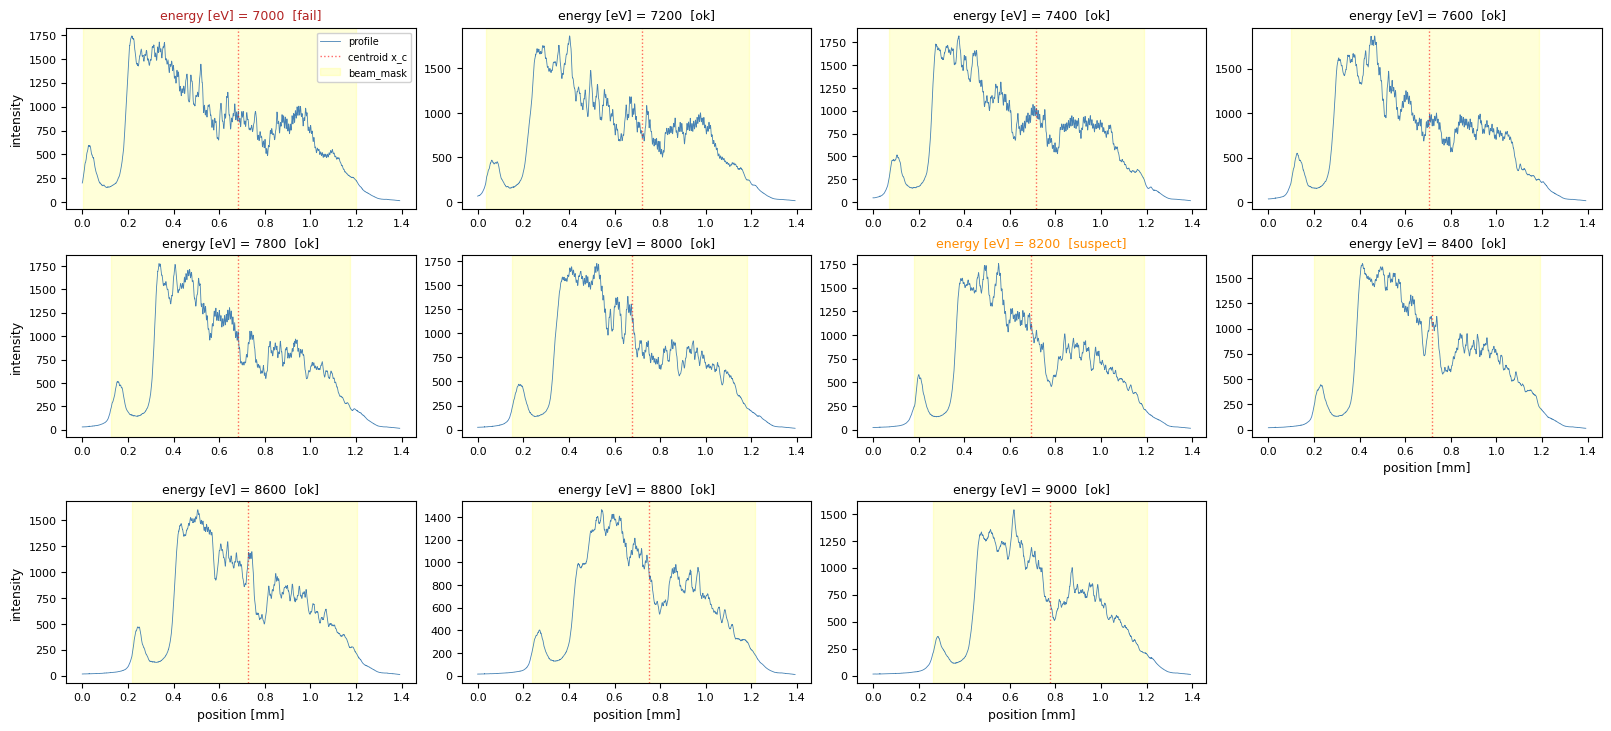

In [39]:
fig, _ = plot_fringe_grid(results_b2, param_b2, flags_b2, label_b2, ncols=4)

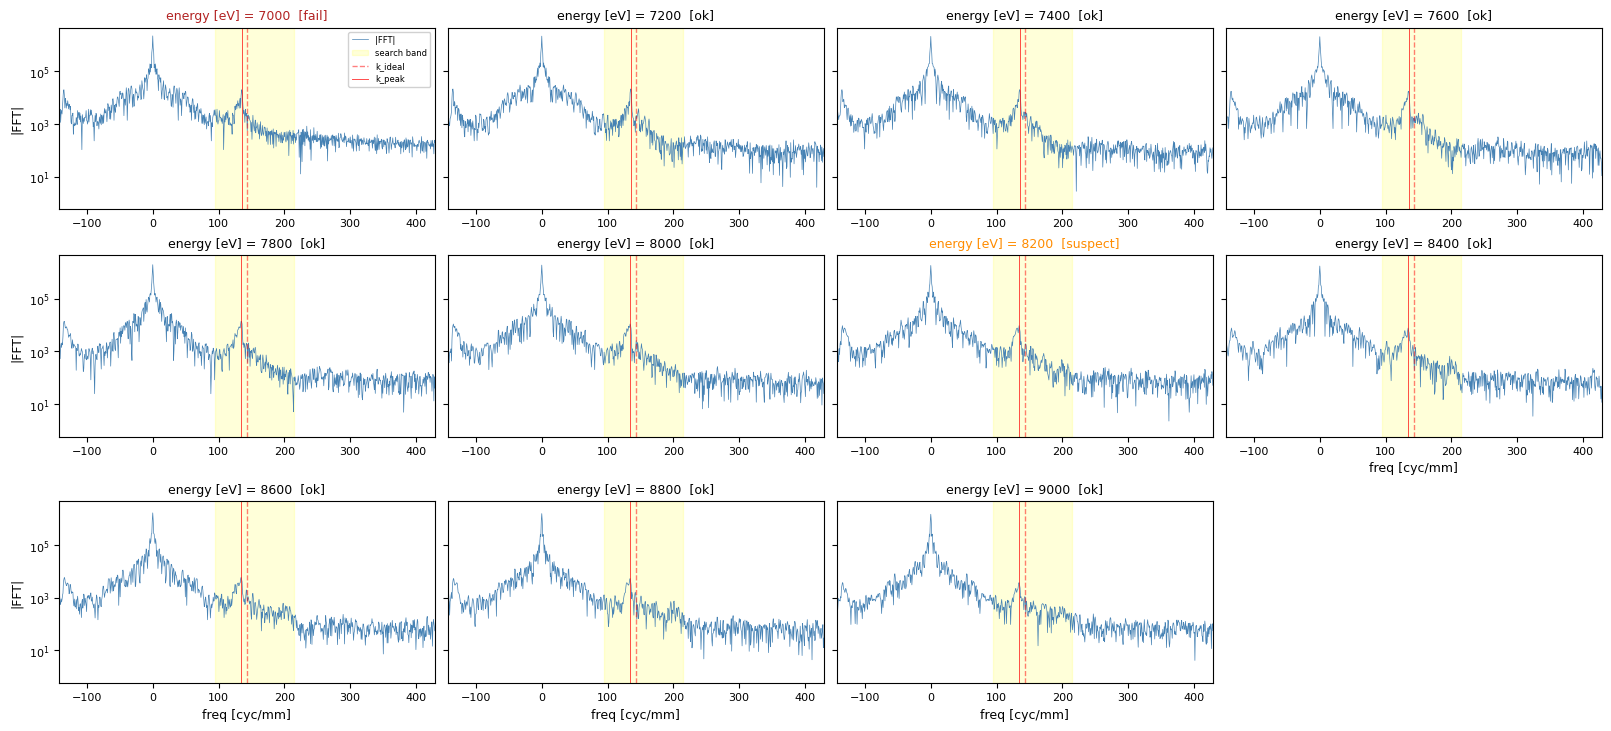

In [40]:
fig, _ = plot_fft_grid(results_b2, param_b2, flags_b2, label_b2, ncols=4)

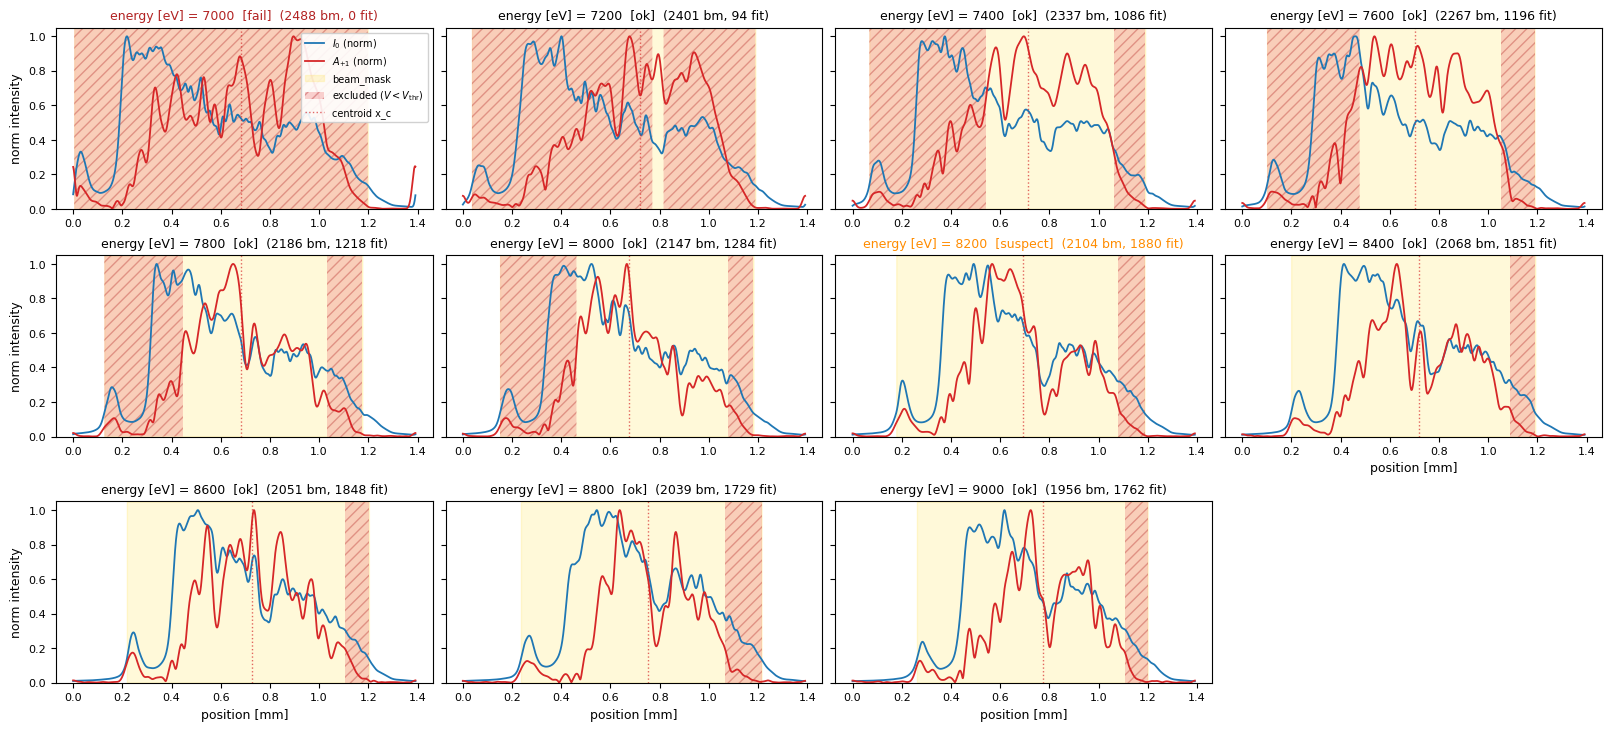

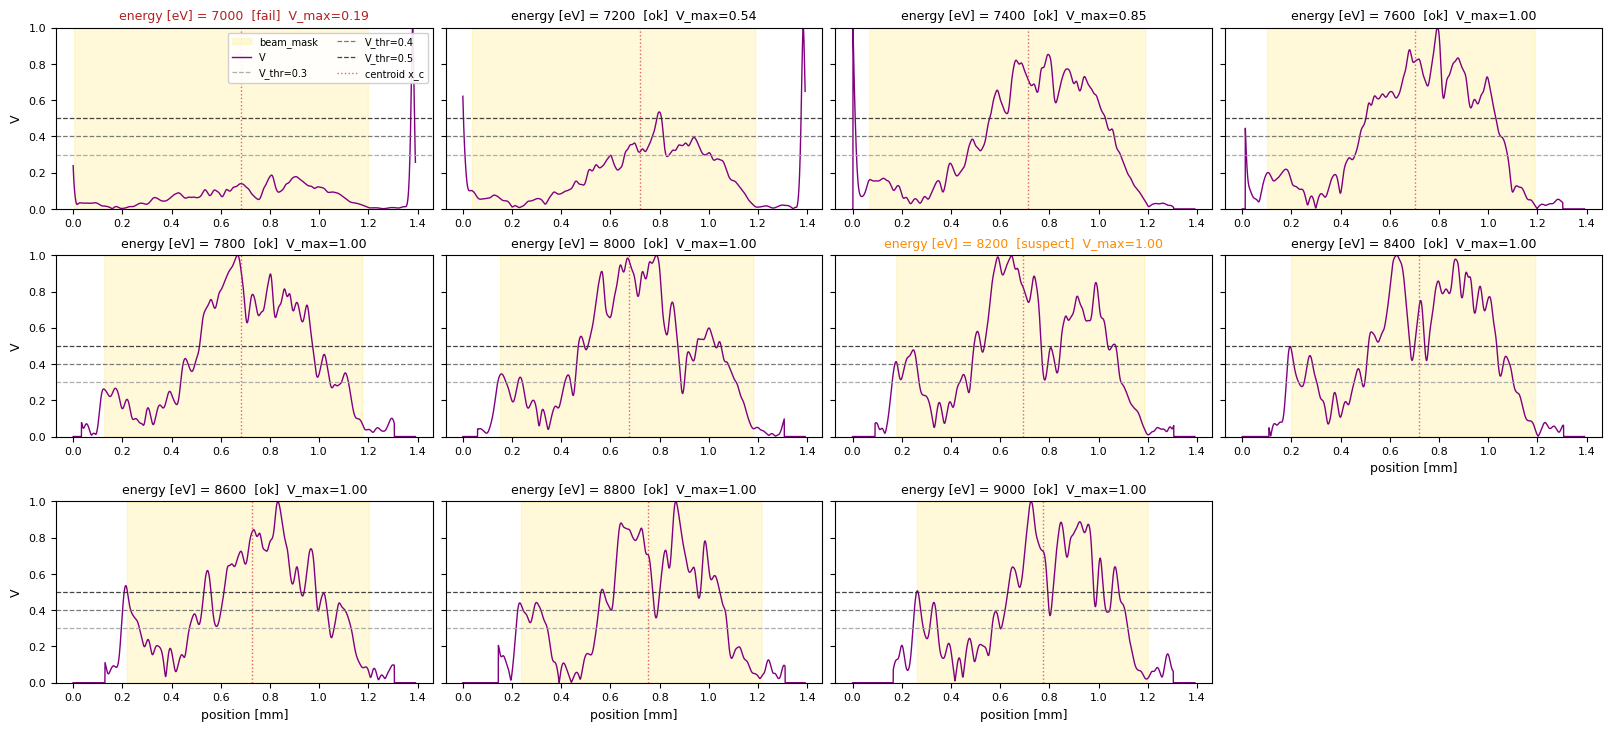

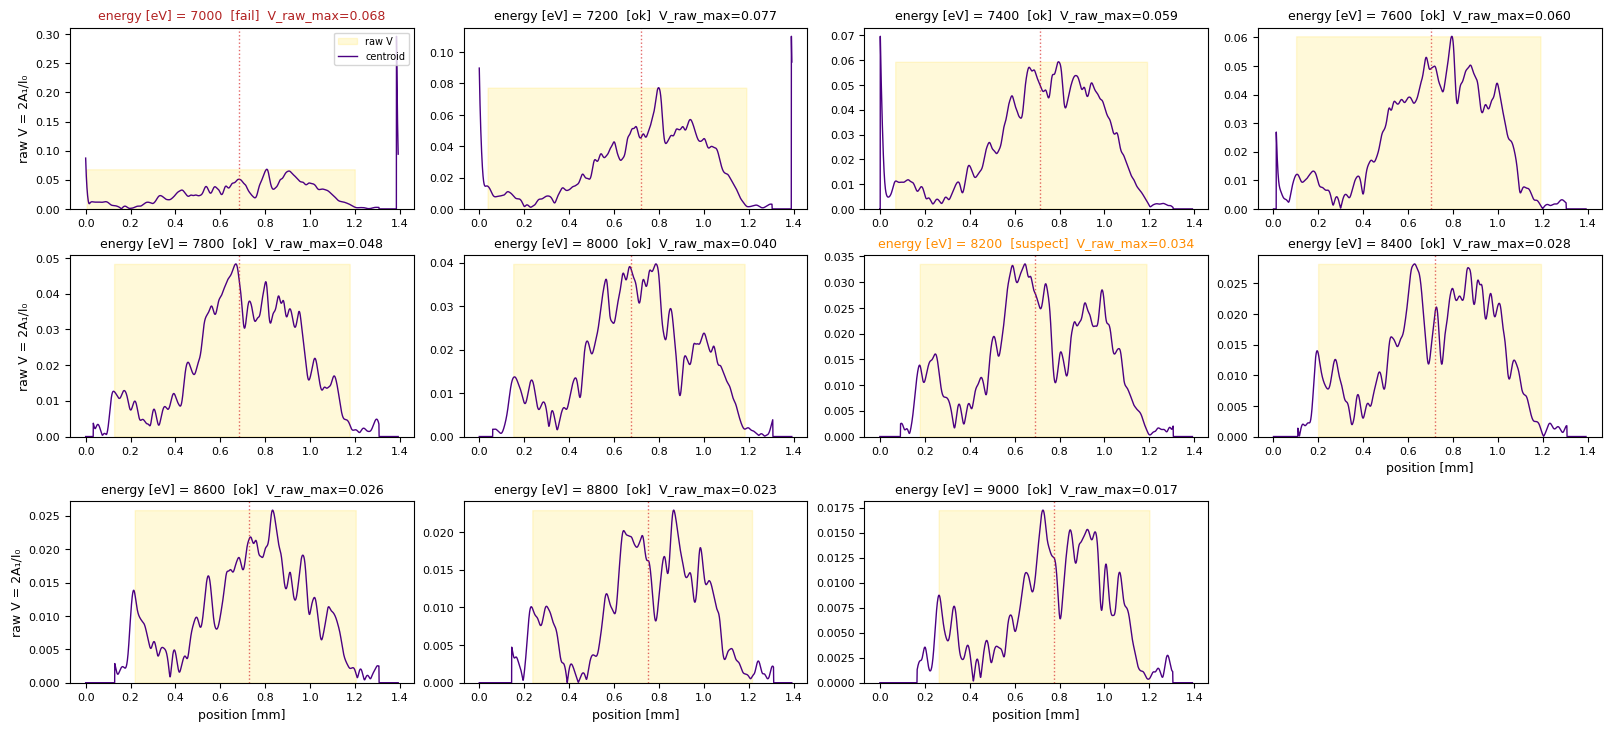

In [46]:
fig, _ = plot_envelope_grid(results_b2, param_b2, flags_b2, label_b2, ncols=4)
fig, _ = plot_V_grid(results_b2, param_b2, flags_b2, label_b2, ncols=4)
fig, _ = plot_raw_V_grid(results_b2, param_b2, flags_b2, label_b2, ncols=4)

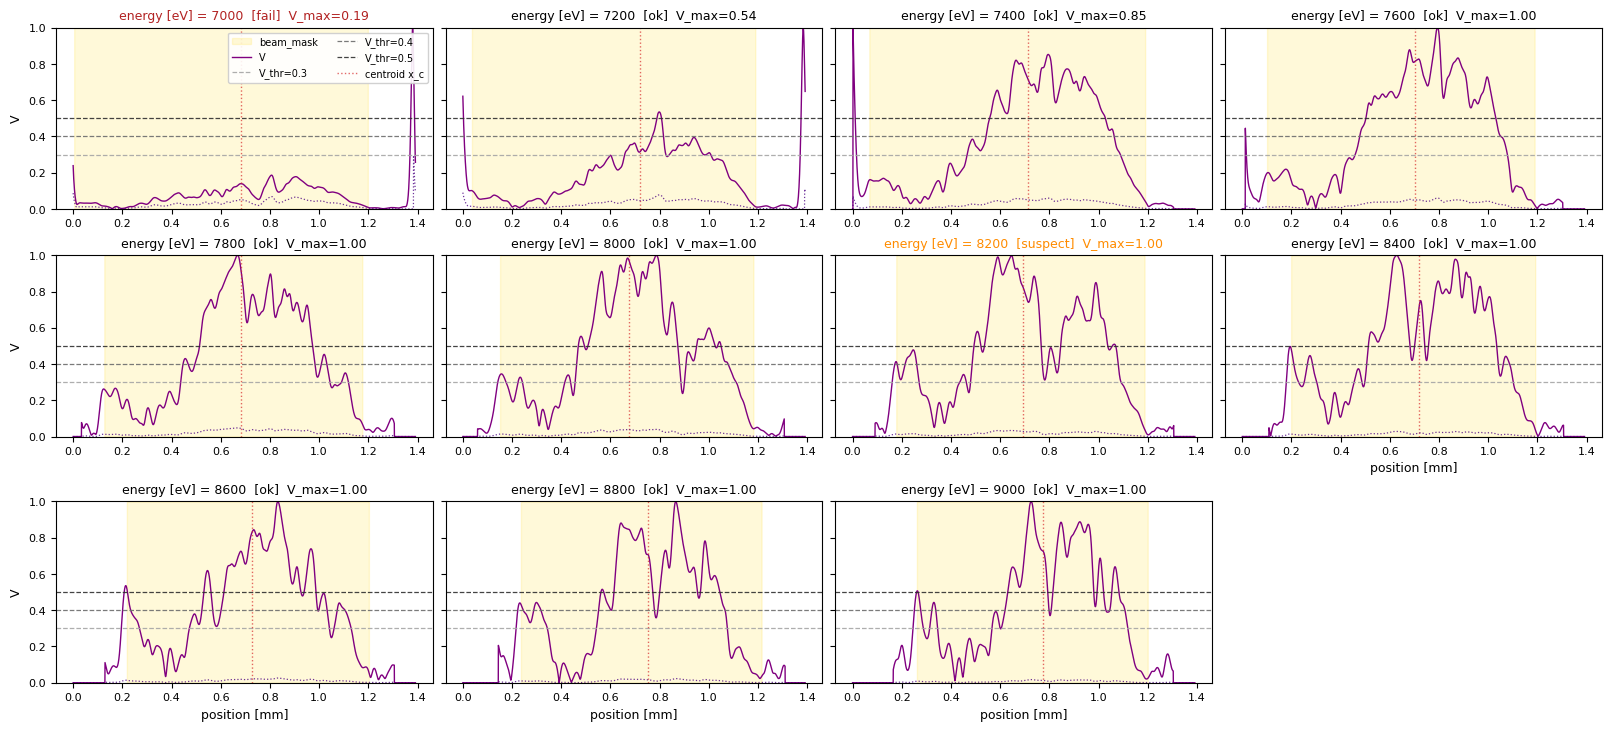

In [44]:
fig, axes = plot_V_grid(results_b2, param_b2, flags_b2, label_b2, ncols=4)
for i, r in enumerate(results_b2):
    x_mm = np.arange(len(r['I0'])) * r['dx'] * 1e3
    axes.flat[i].plot(x_mm, _raw_V(r), color='indigo', ls=':', lw=0.9, alpha=0.8)

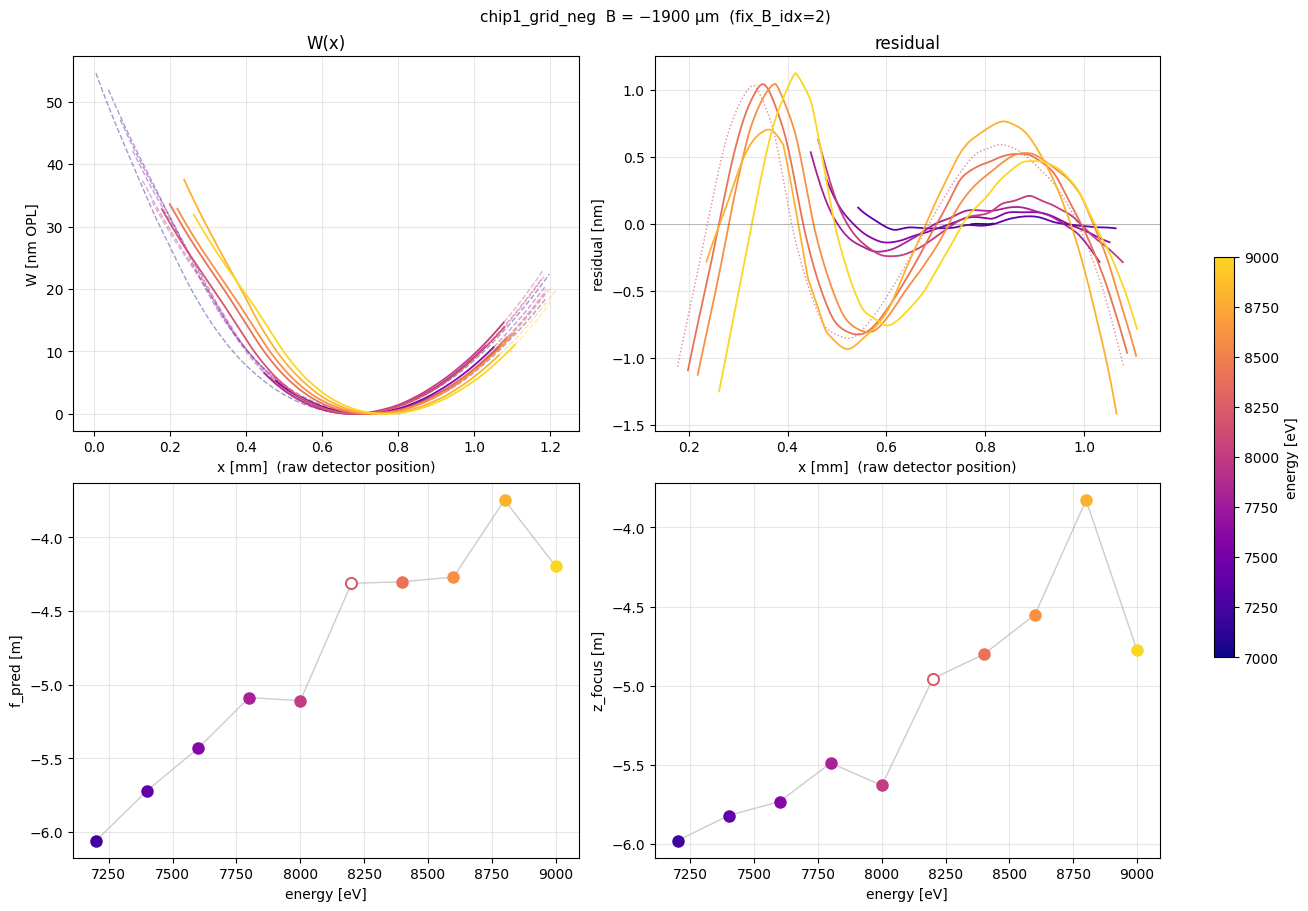

In [42]:
E_vmin, E_vmax = 7000, 9000
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
fig.suptitle('chip1_grid_neg  B = −1900 µm  (fix_B_idx=2)', fontsize=11)

plot_wavefront_overlay(axes[0, 0], results_b2, param_b2, flags_b2,
                       cmap=PLASMA_DARK, x_axis='raw',
                       vmin=E_vmin, vmax=E_vmax)
axes[0, 0].set_title('W(x)')

plot_residual_overlay(axes[0, 1], results_b2, param_b2, flags_b2,
                      cmap=PLASMA_DARK, x_axis='raw',
                      vmin=E_vmin, vmax=E_vmax)
axes[0, 1].set_title('residual')

plot_scalar_vs_param(axes[1, 0], results_b2, param_b2, flags_b2,
                     key='f_pred', cmap=PLASMA_DARK,
                     vmin=E_vmin, vmax=E_vmax)
axes[1, 0].set_xlabel(label_b2)
axes[1, 0].set_ylabel('f_pred [m]')

sm = plot_scalar_vs_param(axes[1, 1], results_b2, param_b2, flags_b2,
                          key='z_focus', cmap=PLASMA_DARK,
                          vmin=E_vmin, vmax=E_vmax)
axes[1, 1].set_xlabel(label_b2)
axes[1, 1].set_ylabel('z_focus [m]')

fig.colorbar(sm, ax=axes.ravel().tolist(), label=label_b2, shrink=0.5)

### Same bender, multi-E

### Same energy, multi-B

In [ ]:
# Quick multi-bender at E=8000 eV.
results_b, param_b, label_b, flags_b = sweep(
    "chip1_grid_neg", fix_E_idx=5, V_threshold=0.0, propagate=False,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

plot_residual_overlay(axes[0], results_b, param_b, flags_b,
                      cmap=PLASMA_DARK, x_axis='raw',
                      vmin=param_b.min(), vmax=param_b.max())
axes[0].set_title('Residual (W − parabolic fit)')

sm = plot_scalar_vs_param(axes[1], results_b, param_b, flags_b,
                          key='f_pred', cmap=PLASMA_DARK,
                          vmin=param_b.min(), vmax=param_b.max())
axes[1].set_xlabel(label_b)
axes[1].set_ylabel('f_pred [m]')
axes[1].set_title('f_pred vs bender')

fig.colorbar(sm, ax=axes, label=label_b)
fig.suptitle('chip1_grid_neg fix_E_idx=5 (E=8000 eV) — '
             'multi-bender',
             fontsize=12)
plt.show()

In [ ]:
# Reconstruct the full chip1_grid_neg grid at V_thr=0 (no filter),
# arrange into (n_E, n_B) and heatmap f_pred.

KEY = "chip1_grid_neg"
images_g, meta_g, info_g = SCANS[KEY]
n_E, n_B = info_g['shape']
E_vals = np.asarray(meta_g['mono_energy_eV'])[::n_B]
B_vals = np.asarray(meta_g['bender_um'])[:n_B]

# Reconstruct every frame
all_recs = [reco_frame(KEY, i, V_threshold=0.0, propagate=False)
            for i in range(n_E * n_B)]

# Reshape f_pred into (n_E, n_B). snake_axes=False → row-major from outer
# (E) to inner (B).
f_pred_grid = np.array([r['f_pred'] for r in all_recs]).reshape(n_E, n_B)

# Plot
fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
dB = B_vals[1] - B_vals[0]
dE = E_vals[1] - E_vals[0]
extent = [B_vals[0] - dB/2, B_vals[-1] + dB/2,
          E_vals[0] - dE/2, E_vals[-1] + dE/2]
im = ax.imshow(f_pred_grid, origin='lower', aspect='auto',
               extent=extent, cmap='RdBu_r',
               vmin=-6, vmax=-2.5)
fig.colorbar(im, ax=ax, label='f_pred [m]')
ax.set_xlabel('bender [µm]')
ax.set_ylabel('energy [eV]')
ax.set_title('chip1_grid_neg — f_pred  (V_thr=0)')
plt.show()

# NOTES
